In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import shap
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Set a random seed for reproducibility
np.random.seed(1234)
random.seed(1234)

In [2]:
# Print the version of the libraries used
print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", xgb.__version__)
print("XGBoost version:", xgb.__version__)
print("Statsmodels version:", sm.__version__)
print("SHAP version:", shap.__version__)

Numpy version: 1.24.4
Pandas version: 2.2.3
Seaborn version: 0.12.2
Scikit-learn version: 3.0.0
XGBoost version: 3.0.0
Statsmodels version: 0.14.0
SHAP version: 0.47.2


In [3]:
def liftatp(scores, Y_test, P):
    """
    Calculate the lift at a specific percentage P
    """
    # Convert Y_test to numpy array if it's a pandas Series
    Y_test = np.array(Y_test)
    
    # sort the scores
    sorted_indices = np.argsort(-scores)
    # and the corresponding labels
    sorted_labels = Y_test[sorted_indices]
    # calculate how many examples make up P percent
    topN = np.floor(np.size(Y_test) * P)
    # select the corresponding labels
    topN_labels = sorted_labels[0:int(topN)]
    # count how many of them are positive
    topN_numberpos = np.size(np.argwhere(topN_labels==1))
    # calculate the lift
    overallPosRate = np.size(np.argwhere(Y_test==1)) / np.size(Y_test)
    topDecilePosRate = topN_numberpos / topN
    return topDecilePosRate / overallPosRate

In [4]:
# Load data from CSV file
# Replace 'your_file.csv' with your actual file path
load_dataset = pd.read_csv('loan_dataset.csv')

# Make loan status binary
load_dataset['loan_status'] = load_dataset['loan_status'].map({'default': 1, 'repaid': 0})

In [5]:
## Create dummy variables for 'application_date' to check correlation with particular time periods
# Convert 'application_date' to datetime
load_dataset['application_date'] = pd.to_datetime(load_dataset['application_date'])

# Create covid-period dummy variable (1 for 2021, 0 otherwise)
load_dataset['covid_period'] = load_dataset['application_date'].dt.year.apply(lambda x: 1 if x == 2021 else 0)

# Create month dummy variable (1-12)
load_dataset['month'] = load_dataset['application_date'].dt.month

# For month dummies
month_dummies = pd.get_dummies(load_dataset['month'], prefix='month').astype(int)
load_dataset = pd.concat([load_dataset, month_dummies], axis=1)

In [6]:
# Get the categorical columns (object dtype), including 'zip_code_prefix'
categorical_columns = load_dataset.select_dtypes(include=['object']).columns.union(['zip_code_prefix'])

# Create dummy variables for each categorical column
# Use drop_first=True to avoid the dummy variable trap
load_dataset_dum = pd.get_dummies(load_dataset[categorical_columns], columns=categorical_columns, drop_first=False).astype(int)

# Concatenate the original dataframe without categorical columns with the dummies
load_dataset_dum = pd.concat([load_dataset.drop(categorical_columns, axis=1), load_dataset_dum], axis=1)

In [7]:
### Generate further variable

## Generate financial variables
load_dataset_dum['monthly_debt_amount'] = load_dataset_dum['debt_to_income_ratio'] * (load_dataset_dum['income'] / 12) # monthly amount of previous debts
load_dataset_dum['savings_to_income_ratio'] = load_dataset_dum['savings_amount'] / load_dataset_dum['income'] # ratio of savings to income
load_dataset_dum['savings_to_loan_ratio'] = load_dataset_dum['savings_amount'] / load_dataset_dum['loan_amount'] # ratio of savings to loan amount
load_dataset_dum['disposable_income'] = (load_dataset_dum['income'] / 12) - load_dataset_dum['monthly_debt_amount'] - load_dataset_dum['monthly_payment'] # disposable income after loan payment
load_dataset_dum['negative_disposable_income'] = load_dataset_dum['disposable_income'].apply(lambda x: 1 if x < 0 else 0) # dummy for negative disposable income
load_dataset_dum['disposable_income'] = load_dataset_dum['disposable_income'].clip(lower=0) # set negative values to 0
load_dataset_dum['dispincome_to_payment_ratio'] = load_dataset_dum['disposable_income'] / load_dataset_dum['monthly_payment'] # ratio disposable income to loan payment

# Zip code risk proxy (using historical defaults) to avoid discrimination
zip_risk = load_dataset.groupby('zip_code_prefix')['previous_defaults'].mean().to_dict()
load_dataset_dum['zip_default_risk'] = load_dataset['zip_code_prefix'].map(zip_risk)

# Generate age bins to risk proxy as for the zip code
load_dataset_dum['age_group'] = pd.cut(load_dataset_dum['age'],
                         bins=[18, 24, 40, 60, 70],
                         labels=[1,2,3,4],
                         include_lowest=True).astype(int)
age_risk = load_dataset_dum.groupby('age_group')['previous_defaults'].mean().to_dict()
load_dataset_dum['age_default_risk'] = load_dataset_dum['age_group'].map(age_risk)
load_dataset_dum['age_term_ratio'] = load_dataset_dum['loan_term_months'] / load_dataset_dum['age'] # ratio of loan term to age

# Generate customer dependency variable
load_dataset_dum['newcust_cosigner'] = (1-load_dataset_dum['existing_customer']) * load_dataset_dum['has_cosigner']
load_dataset_dum['newcust_nocosigner'] = (1-load_dataset_dum['existing_customer']) * (1-load_dataset_dum['has_cosigner'])

## Generate quartiles variables and dummies
# Income quartiles
load_dataset_dum['income_quartile'] = pd.qcut(load_dataset_dum['income'],
                                q=4,
                                labels=[1,2,3,4]).astype(int)
income_dummies = pd.get_dummies(load_dataset_dum['income_quartile'], prefix='income_quartile').astype(int)
load_dataset_dum = pd.concat([load_dataset_dum, income_dummies], axis=1)


# Debt-to-income ratio quartiles
load_dataset_dum['loan_to_income_quartile'] = pd.qcut(load_dataset_dum['loan_to_income_ratio'],
                                q=4,
                                labels=[1,2,3,4]).astype(int)
debt_to_income_dummies = pd.get_dummies(load_dataset_dum['loan_to_income_quartile'], prefix='loan_to_income_quartile').astype(int)
load_dataset_dum = pd.concat([load_dataset_dum, debt_to_income_dummies], axis=1)

# Saving ratio quartiles
load_dataset_dum['sav_ratio_quartile'] = pd.qcut(load_dataset_dum['savings_to_income_ratio'],
                                q=4,
                                labels=[1,2,3,4]).astype(int)
savings_ratio_dummies = pd.get_dummies(load_dataset_dum['sav_ratio_quartile'], prefix='savings_to_income_quartile').astype(int)
load_dataset_dum = pd.concat([load_dataset_dum, savings_ratio_dummies], axis=1)

# Disposable income quartiles
load_dataset_dum['dispincome_quantile'] = pd.qcut(load_dataset_dum['disposable_income'],
                                q=4,
                                labels=[1,2,3,4]).astype(int)
disposable_income_dummies = pd.get_dummies(load_dataset_dum['dispincome_quantile'], prefix='disposable_income_quartile').astype(int)
load_dataset_dum = pd.concat([load_dataset_dum, disposable_income_dummies], axis=1)

In [8]:
# Display the shape before and after creating dummies
print(f"Original dataframe shape: {load_dataset.shape}")
print(f"Dataframe with dummies shape: {load_dataset_dum.shape}")

Original dataframe shape: (50000, 36)
Dataframe with dummies shape: (50000, 83)


Correlations with loan_status_default (sorted):
loan_status                    1.000000
debt_to_income_ratio           0.109479
previous_defaults              0.092579
loan_to_income_ratio           0.081242
payment_to_income_ratio        0.069202
                                 ...   
loan_to_income_quartile_1     -0.050262
dispincome_to_payment_ratio   -0.061886
disposable_income             -0.064600
savings_to_loan_ratio         -0.067038
credit_score                  -0.518762
Name: loan_status, Length: 76, dtype: float64


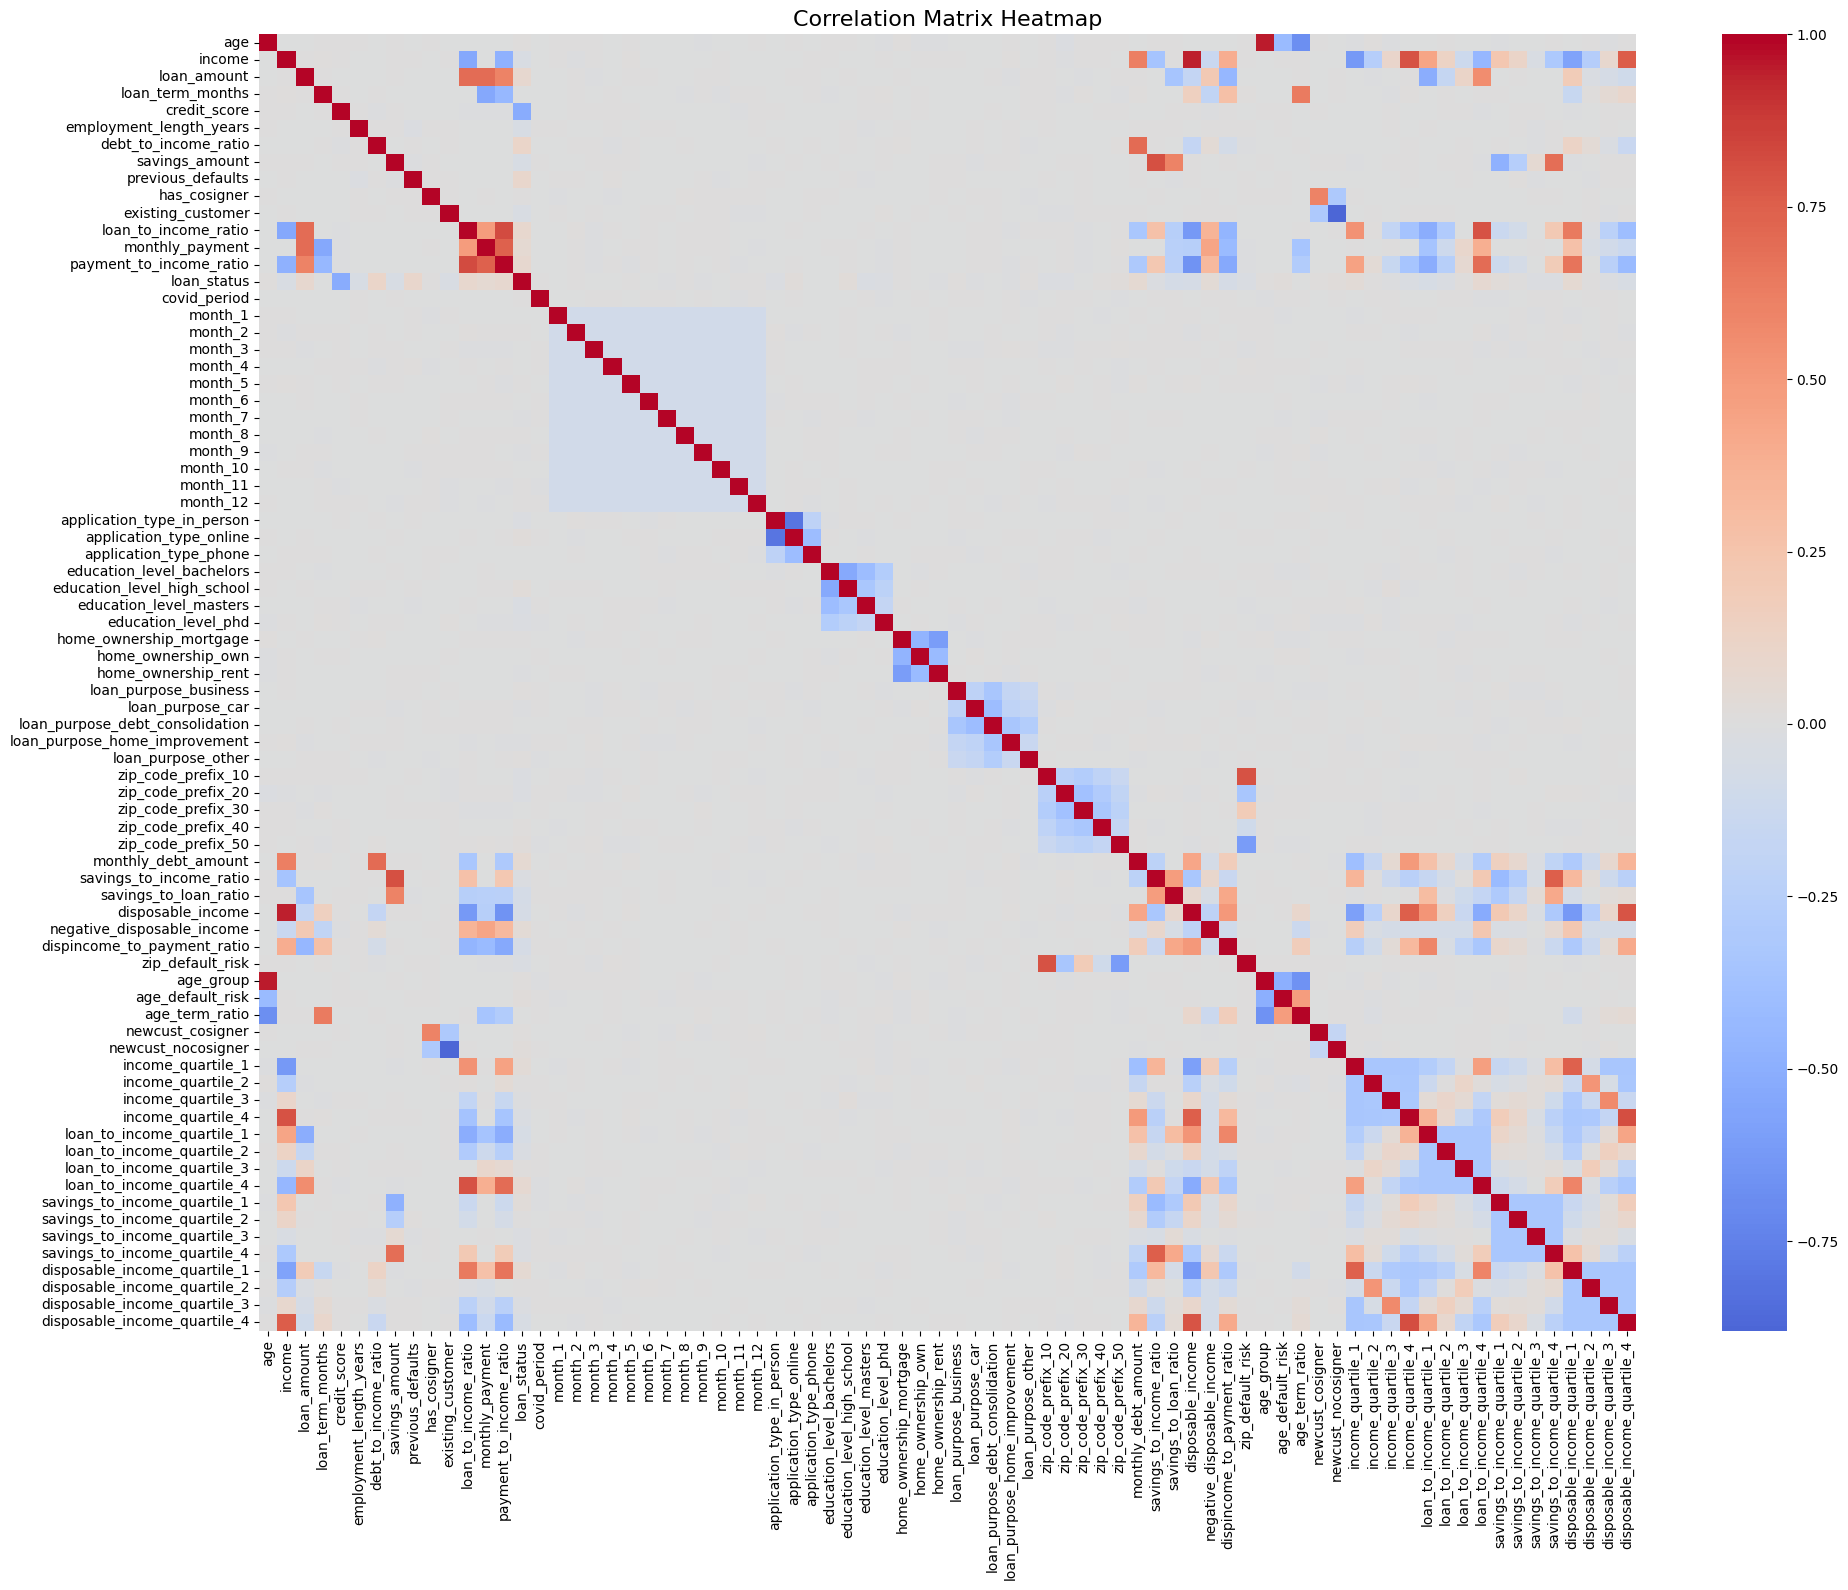

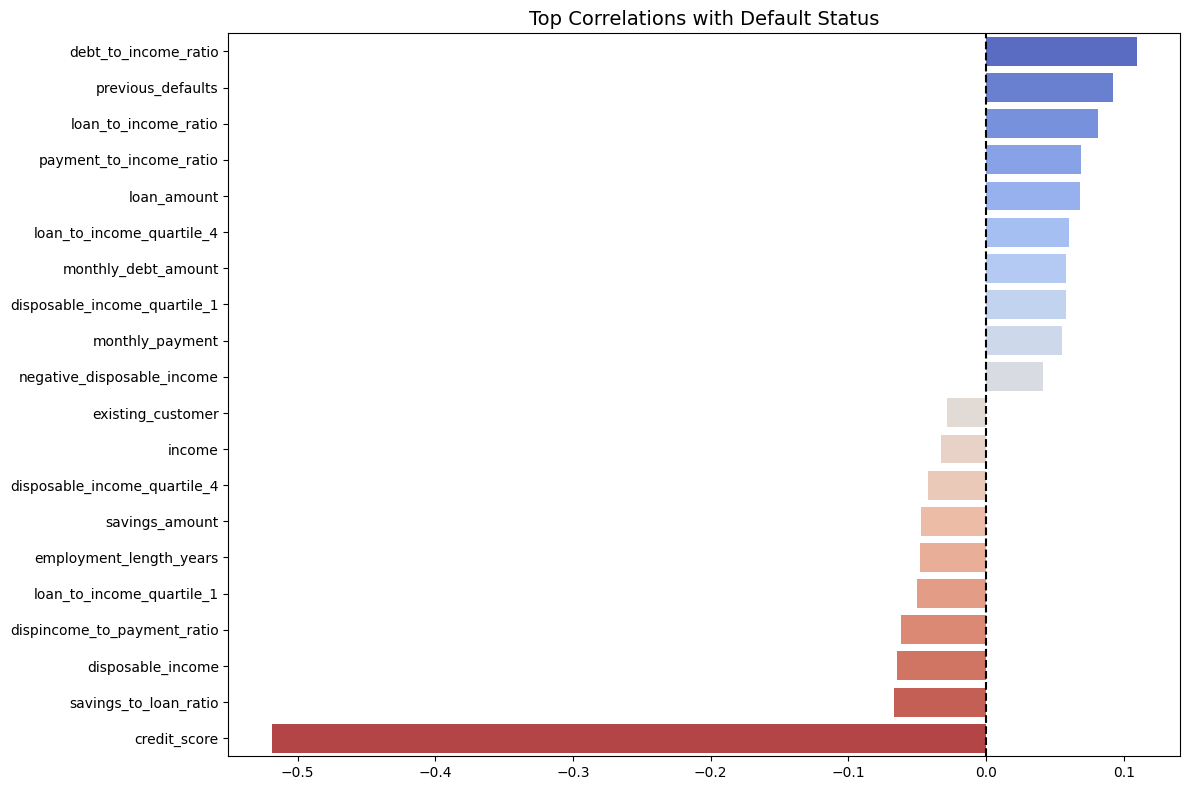

In [9]:
# Calculate correlations
# Using load_dataset_dum since it contains the encoded categorical variables
correlation_matrix = load_dataset_dum.drop(['application_date', 'customer_id', 'month', 'income_quartile', 'sav_ratio_quartile', 'dispincome_quantile', 'loan_to_income_quartile'], axis=1).corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.tight_layout()

# Look at the correlations with loan_status_default specifically
loan_status_corr = correlation_matrix['loan_status'].sort_values(ascending=False)
print("Correlations with loan_status_default (sorted):")
print(loan_status_corr)

# Display top 10 positive and negative correlations with loan_status_default
plt.figure(figsize=(12, 8))
loan_status_corr_filtered = loan_status_corr[loan_status_corr.index != 'loan_status']
top_corrs = pd.concat([
    loan_status_corr_filtered.head(10),
    loan_status_corr_filtered.tail(10)
])
sns.barplot(x=top_corrs.values, y=top_corrs.index, palette='coolwarm')
plt.title('Top Correlations with Default Status', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()

In [10]:
## Defining the target and features
target = 'loan_status'
features = load_dataset_dum.drop(columns=[target, 'customer_id', 'application_date', 'month', 'zip_code_prefix_10', 'zip_code_prefix_20', 'zip_code_prefix_30', 'zip_code_prefix_40', 'zip_code_prefix_50', 'age_group', 'age', 'income_quartile', 'sav_ratio_quartile', 'dispincome_quantile', 'loan_to_income_quartile'])

# Preprocessing
X = features
y = load_dataset_dum[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Accuracy Test for Logistic Regression: 0.7712
AUC Test for Logistic Regression: 0.8347024781554974
Best parameters: {'classifier__C': 0.1, 'classifier__max_iter': 1000, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}


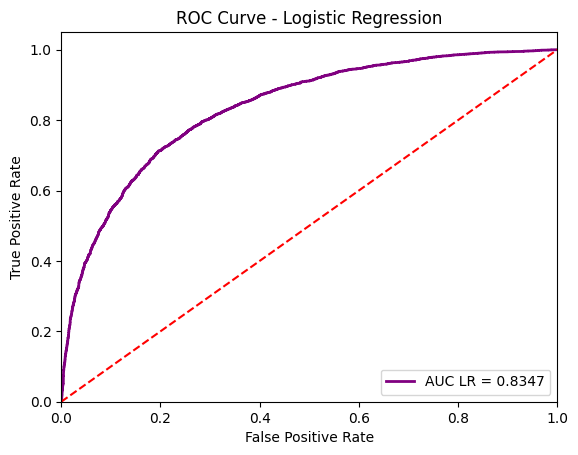

Confusion Matrix:
[[5375  948]
 [1340 2337]]


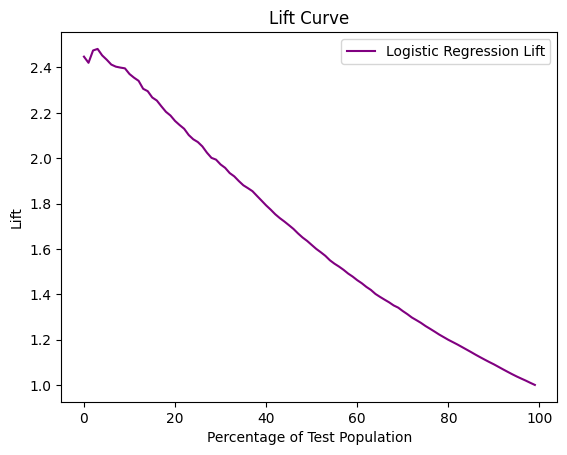

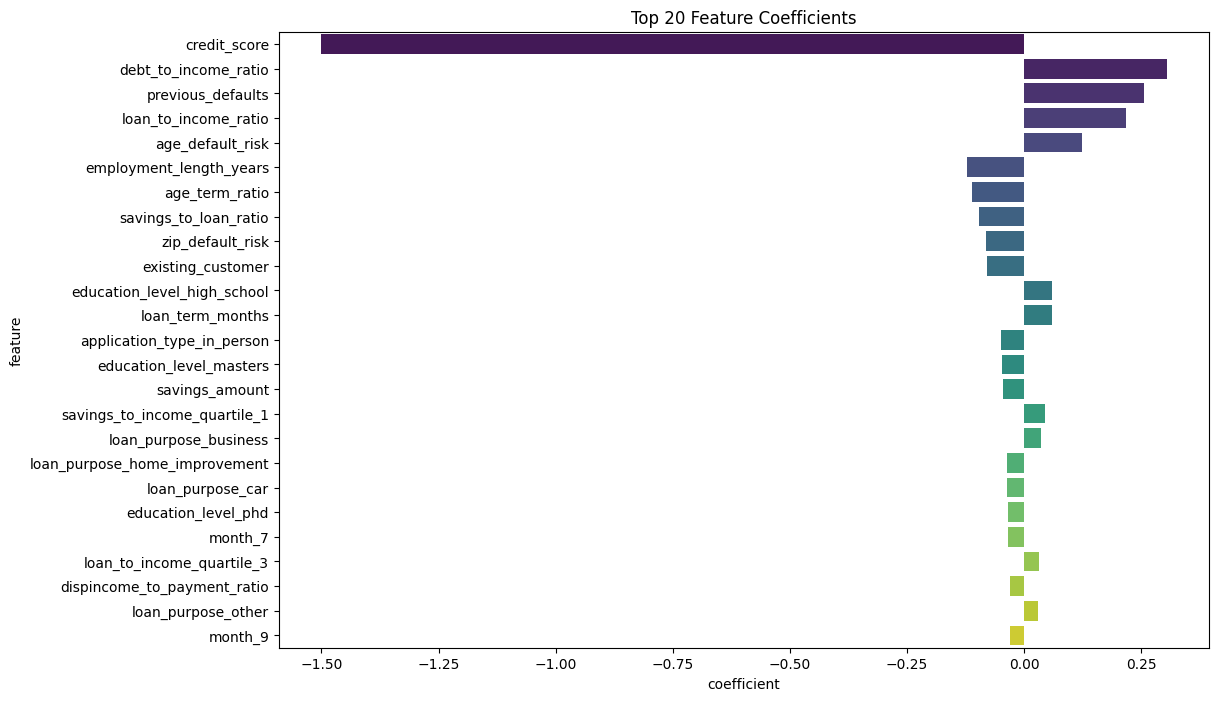

SHAP Feature Importance:


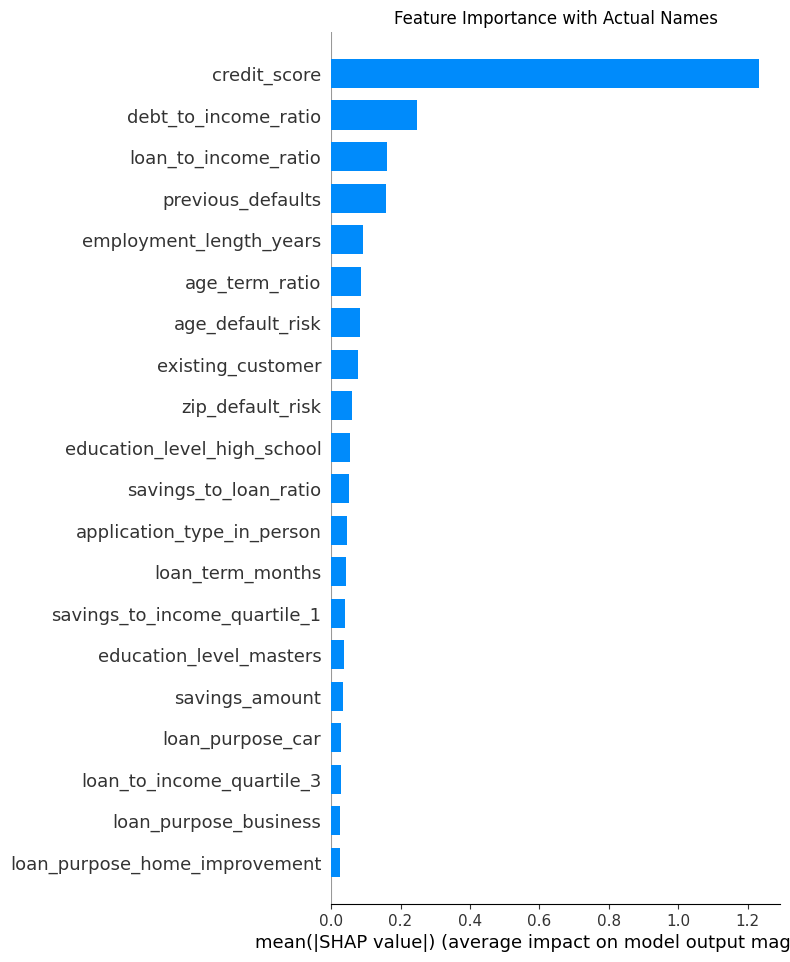

SHAP Value Distribution:


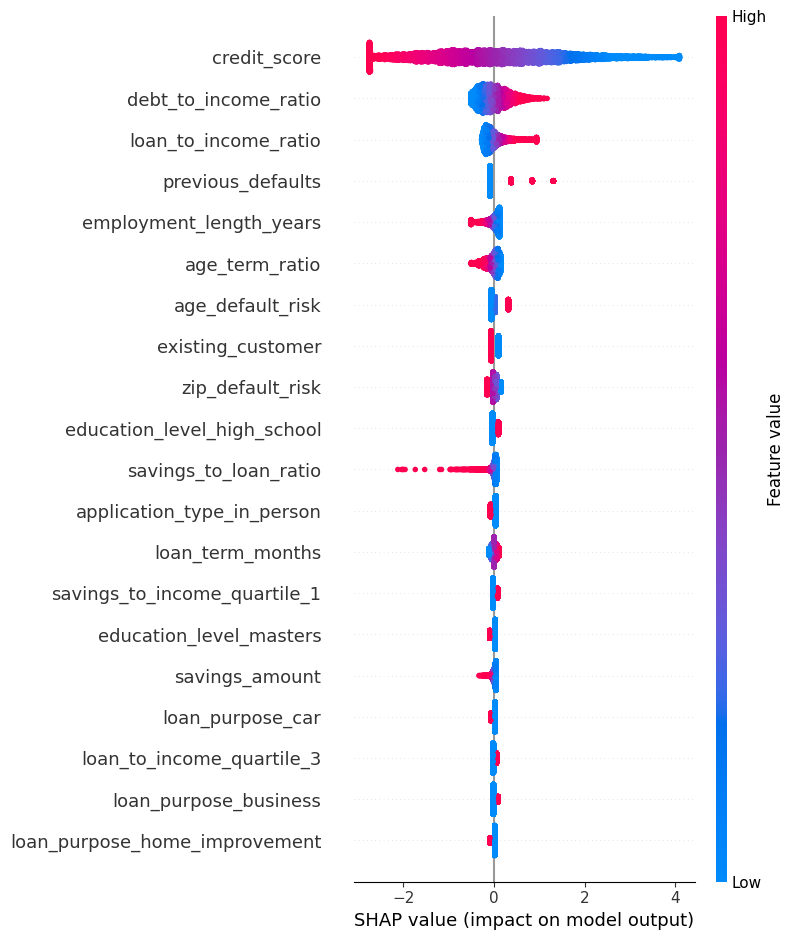

Force Plot for First Sample:


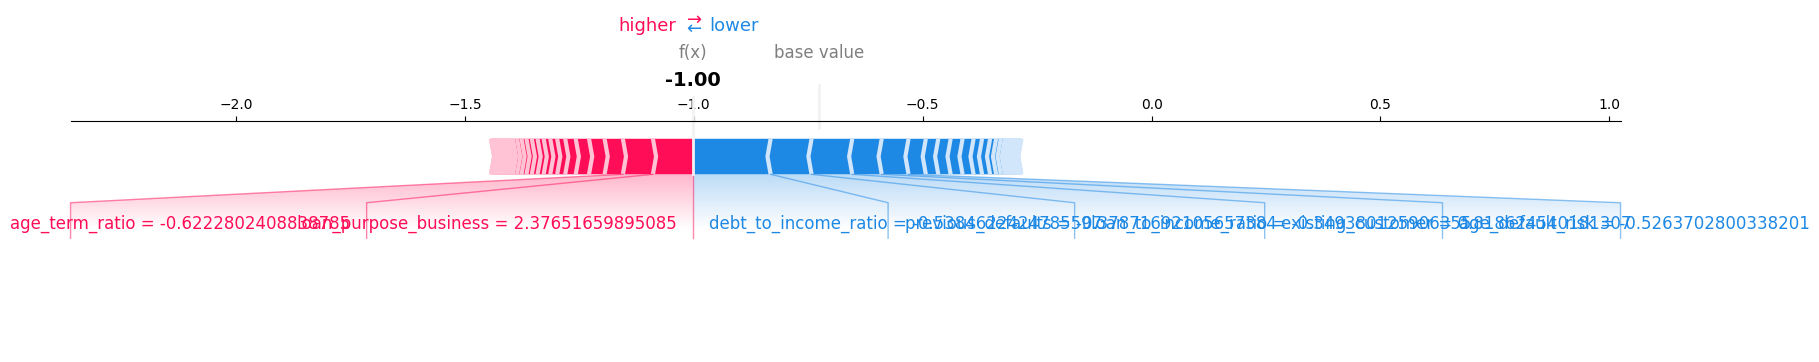


Waterfall Plot for First Sample:


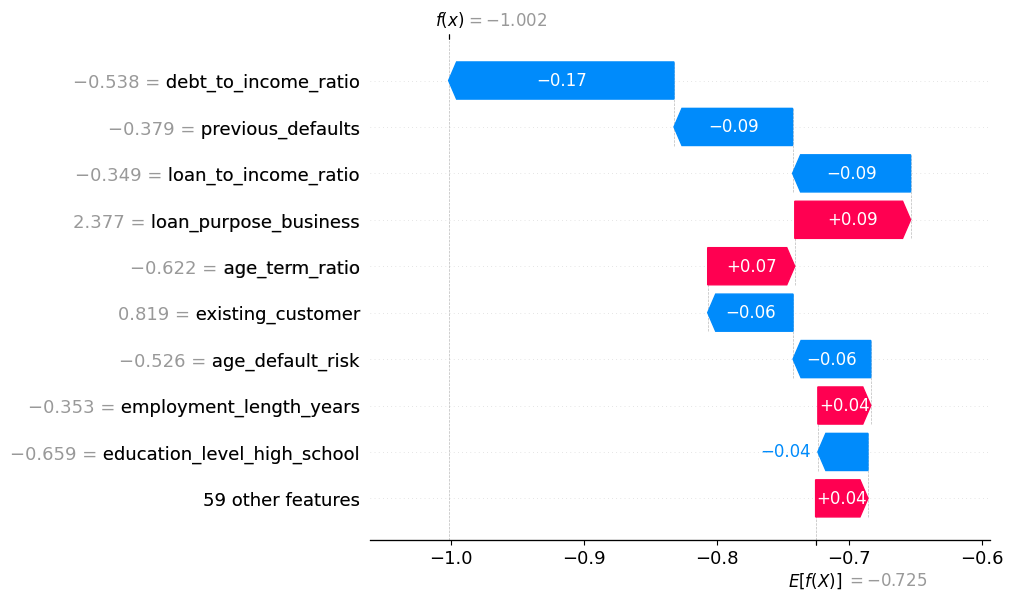

In [ ]:
## Logistic Regression
# Create pipeline with preprocessing
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),  # Important for logistic regression
    ('classifier', LogisticRegression())
])

# Parameter grid (note solver-penalty compatibility)
param_grid_lr = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse regularization strength
    'classifier__penalty': ['l1', 'l2'],                # Regularization type
    'classifier__solver': ['liblinear', 'saga'],        # Optimization algorithms
    'classifier__max_iter': [500, 1000]                 # Convergence iterations
}

# Perform grid search with cross-validation
gridsearch_lr = GridSearchCV(
    lr_pipe,
    param_grid_lr,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1234),
    n_jobs=-1,
    verbose=1,
)
gridsearch_lr.fit(X_train, np.ravel(y_train))

# Get the best model
LR = gridsearch_lr.best_estimator_

# Generate predictions
y_test_labels_lr = LR.predict(X_test)
y_test_scores_lr = LR.predict_proba(X_test)[:,1]

# Evaluate performance
accuracy_test_lr = accuracy_score(y_test, y_test_labels_lr)
AUC_test_lr = roc_auc_score(y_test, y_test_scores_lr)
print(f"Accuracy Test for Logistic Regression: {accuracy_test_lr}")
print(f"AUC Test for Logistic Regression: {AUC_test_lr}")
print(f"Best parameters: {gridsearch_lr.best_params_}")

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_scores_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.figure()
plt.plot(fpr_lr, tpr_lr, color='purple', lw=2, label=f'AUC LR = {roc_auc_lr:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cf_lr = confusion_matrix(y_test, y_test_labels_lr)
print("Confusion Matrix for Logistic Regression:")
print(cf_lr)

# Lift Curve
lift_curve_LR = [liftatp(y_test_scores_lr, y_test, (i+1)/100) for i in range(100)]
plt.plot(np.arange(100), lift_curve_LR, 'purple', label='Logistic Regression Lift')
plt.title('Lift Curve')
plt.xlabel('Percentage of Test Population')
plt.ylabel('Lift')
plt.legend()
plt.show()

# Store metrics
y_test_evaluation_lr = pd.DataFrame({
    'accuracy': [accuracy_test_lr],
    'AUC': [AUC_test_lr]
})

# Coefficient Visualization
coefficients_lr = LR.named_steps['classifier'].coef_[0]
feature_importance_lr = pd.DataFrame({
    'feature': X.columns,
    'coefficient': coefficients_lr
}).sort_values(by='coefficient', key=abs, ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='coefficient', y='feature', data=feature_importance_lr.head(25), palette='viridis')
plt.title('Top 20 Feature Coefficients')
plt.show()

## SHAP analysis
# Scale data using the pipeline's scaler
X_train_scaled = LR.named_steps['scaler'].transform(X_train)

X_test_scaled = LR.named_steps['scaler'].transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Initialize SHAP explainer
explainer_lr = shap.LinearExplainer(
    model=LR.named_steps['classifier'],
    masker=shap.maskers.Independent(X_train_scaled, max_samples=1000),
    feature_perturbation="interventional"
)

# Calculate SHAP values
shap_values_lr = explainer_lr(X_test_scaled)

# Create Explanation object with binary class handling
shap_explanation = shap.Explanation(
    values=shap_values_lr.values[:, :, 1] if len(shap_values_lr.shape) == 3 else shap_values_lr.values,
    base_values=shap_values_lr.base_values[:, 1] if len(shap_values_lr.base_values.shape) == 2 else shap_values_lr.base_values,
    data=X_test_scaled,
    feature_names=X.columns.tolist()
)

# SHAP visualizations
print("SHAP Feature Importance:")
shap.summary_plot(shap_explanation, plot_type="bar", show=False)
plt.title("Feature Importance with Actual Names")
plt.show()

print("SHAP Value Distribution:")
shap.summary_plot(shap_values_lr, X_test_scaled, feature_names=X.columns)

print("Force Plot for First Sample:")
shap.initjs()
shap.plots.force(shap_values_lr[0], matplotlib=True)

print("\nWaterfall Plot for First Sample:")
shap.plots.waterfall(shap_values_lr[0])

In [12]:
## Keep only the best features and further manual selection
# Select features based on Logistic Regression coefficients
# Get the top 25 features from feature importance
top_features = feature_importance_lr.head(25)['feature'].tolist()

# Add additional important features
additional_features = ['monthly_payment', 'income', 'has_cosigner', 
                      'disposable_income_quartile_1', 'dispincome_to_payment_ratio', 
                      'month_12']

# Combine all features
selected_features_lr = top_features + additional_features

# Remove any duplicates (in case some features appear in both lists)
selected_features_lr = list(dict.fromkeys(selected_features_lr))

# Select only the chosen features from the datasets
X_selected = X[selected_features_lr]
X_train_selected = X_train[selected_features_lr]
X_test_selected = X_test[selected_features_lr]

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Accuracy Test for Logistic Regression: 0.7735
AUC Test for Logistic Regression: 0.8345536158339617
Best parameters: {'classifier__C': 100, 'classifier__max_iter': 1000, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


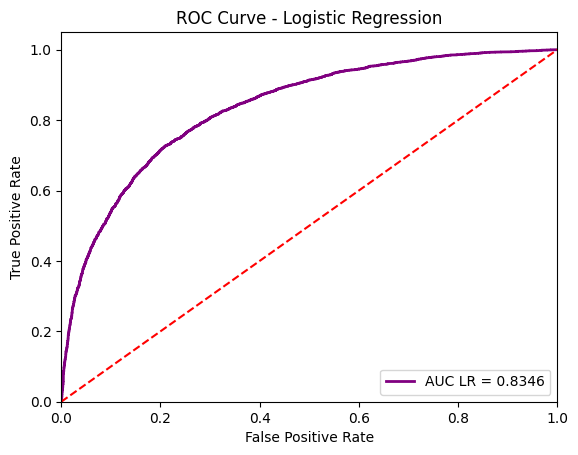

Confusion Matrix for Logistic Regression with selected features:
[[5381  942]
 [1323 2354]]


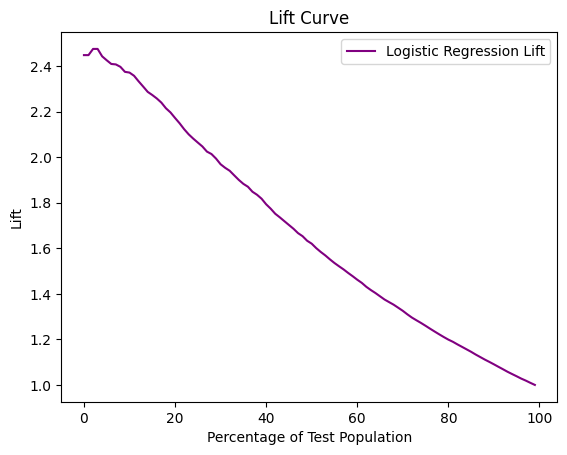

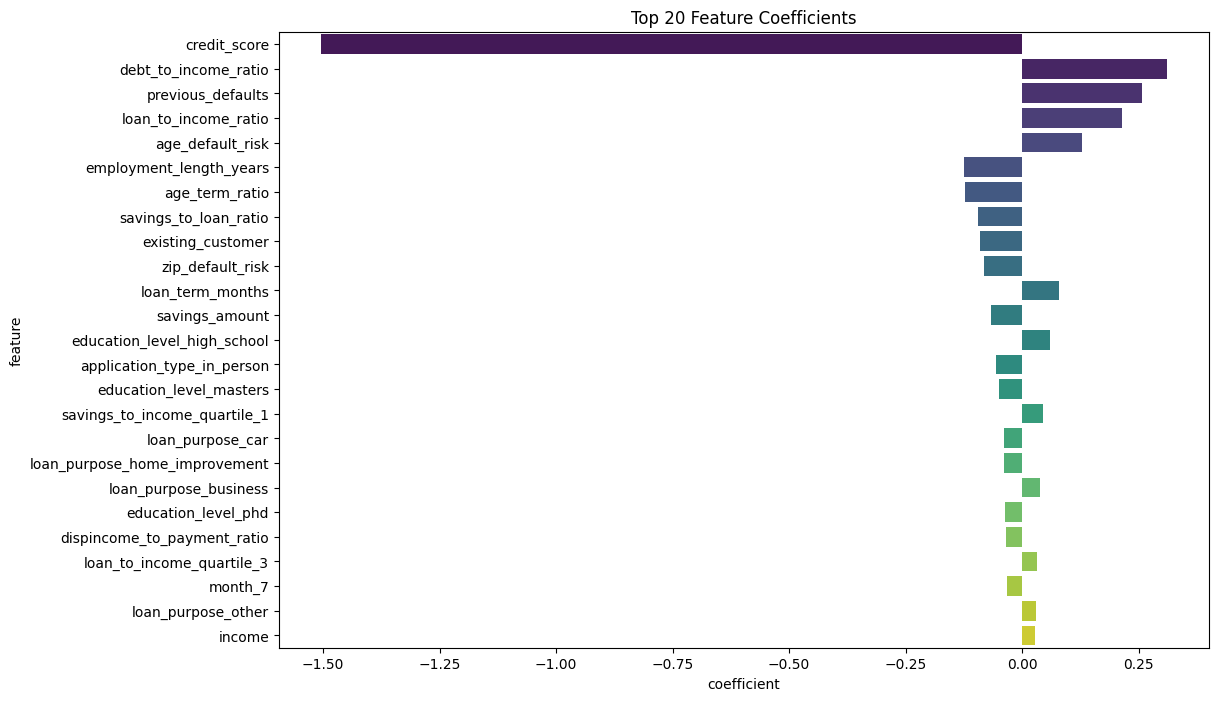

SHAP Feature Importance:


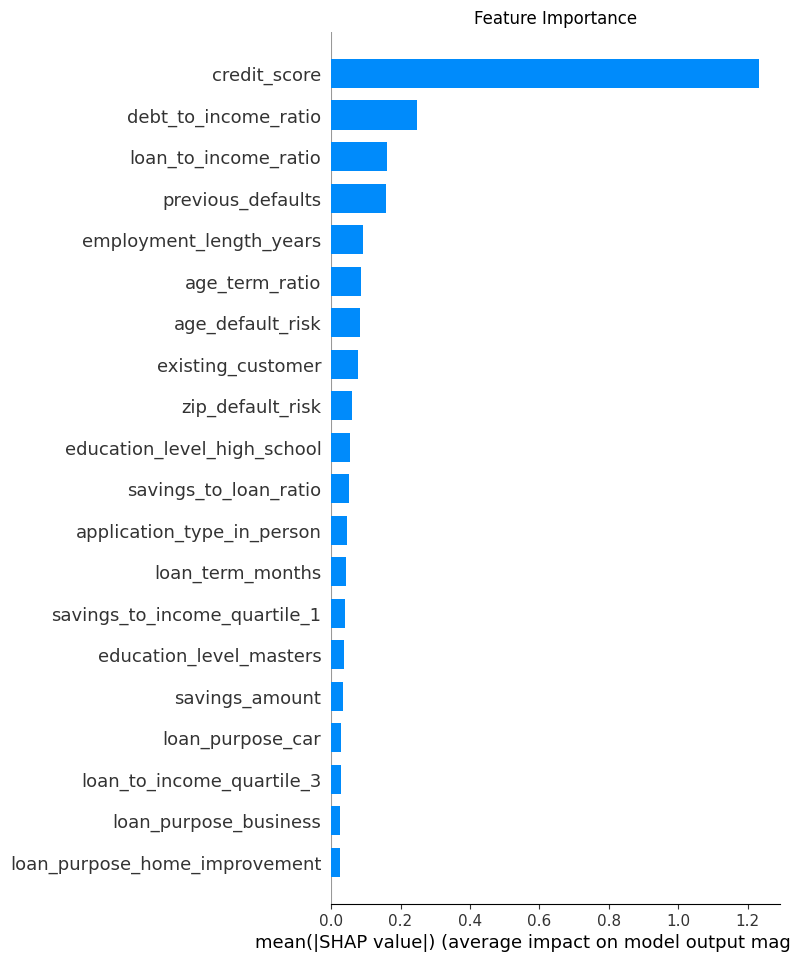

SHAP Value Distribution:


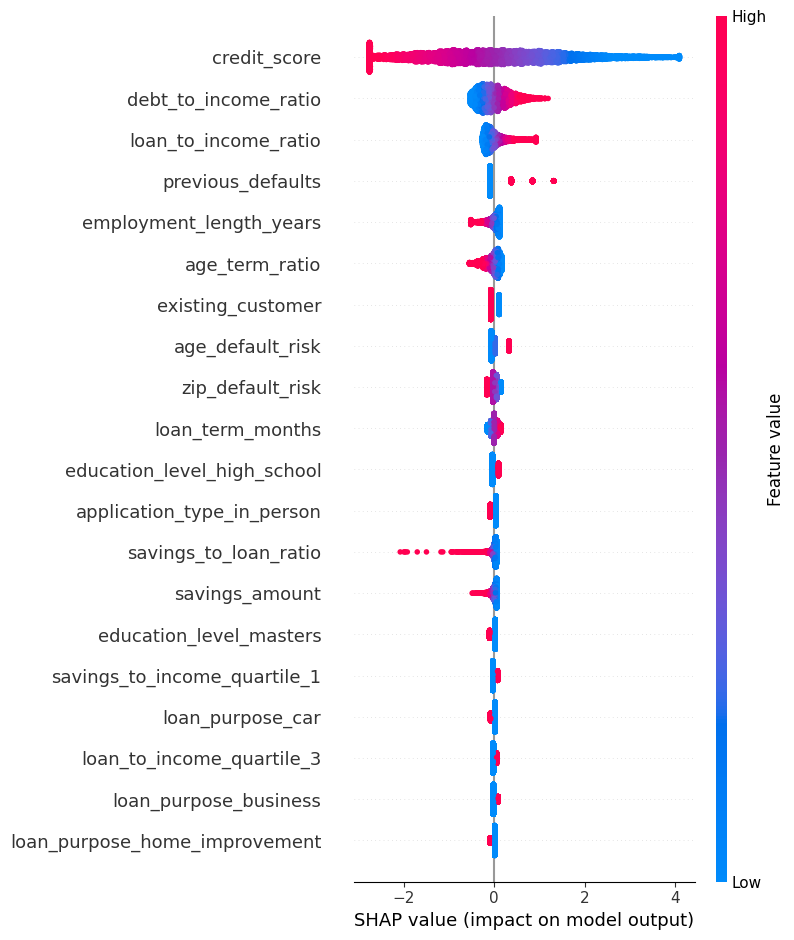

Force Plot for First Sample:


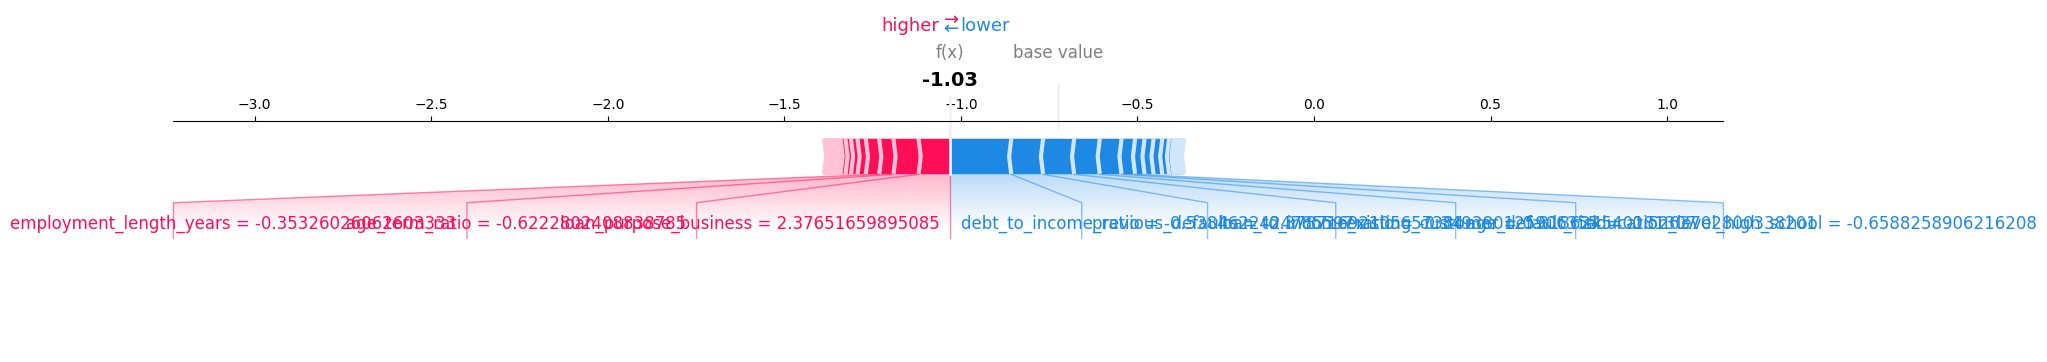


Waterfall Plot for First Sample:


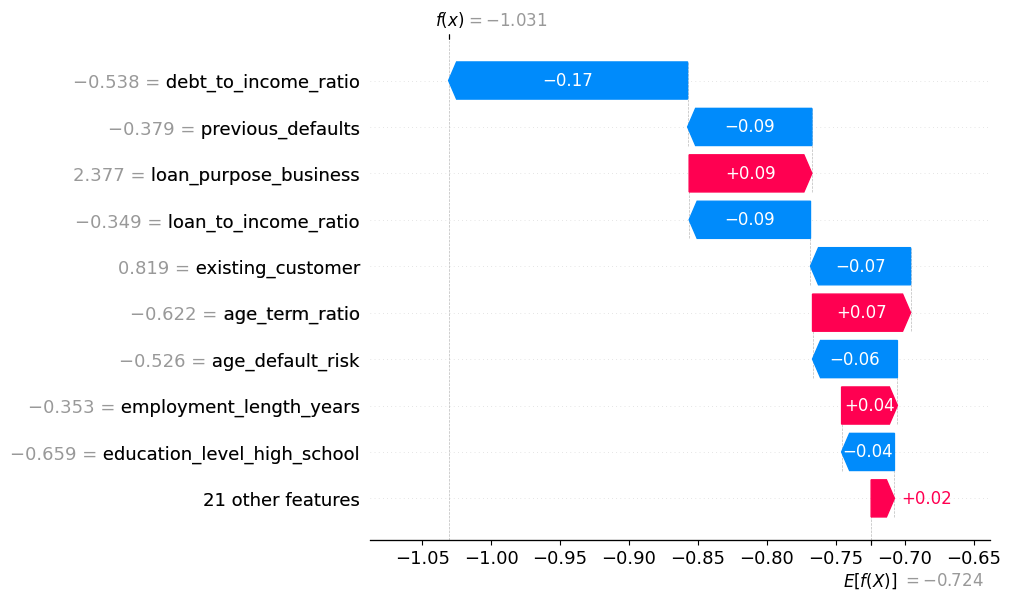

In [49]:
## Logistic Regression with selected features
# Create pipeline with preprocessing
lr_pipe2 = Pipeline([
    ('scaler', StandardScaler()),  # Important for logistic regression
    ('classifier', LogisticRegression())
])

# Parameter grid (note solver-penalty compatibility)
param_grid_lr2 = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse regularization strength
    'classifier__penalty': ['l1', 'l2'],                # Regularization type
    'classifier__solver': ['liblinear', 'saga'],        # Optimization algorithms
    'classifier__max_iter': [500, 1000]                 # Convergence iterations
}

# Perform grid search with cross-validation
gridsearch_lr2 = GridSearchCV(
    lr_pipe2,
    param_grid_lr2,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1234),
    n_jobs=-1,
    verbose=1,
)
gridsearch_lr2.fit(X_train_selected, np.ravel(y_train))

# Get the best model
LR2 = gridsearch_lr2.best_estimator_

# Generate predictions
y_test_labels_lr2 = LR2.predict(X_test_selected)
y_test_scores_lr2 = LR2.predict_proba(X_test_selected)[:,1]

# Evaluate performance
accuracy_test_lr2 = accuracy_score(y_test, y_test_labels_lr2)
AUC_test_lr2 = roc_auc_score(y_test, y_test_scores_lr2)
print(f"Accuracy Test for Logistic Regression: {accuracy_test_lr2}")
print(f"AUC Test for Logistic Regression: {AUC_test_lr2}")
print(f"Best parameters: {gridsearch_lr2.best_params_}")

# ROC Curve
fpr_lr2, tpr_lr2, _ = roc_curve(y_test, y_test_scores_lr2)
roc_auc_lr2 = auc(fpr_lr2, tpr_lr2)
plt.figure()
plt.plot(fpr_lr2, tpr_lr2, color='purple', lw=2, label=f'AUC LR = {roc_auc_lr2:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cf_lr2 = confusion_matrix(y_test, y_test_labels_lr2)
print("Confusion Matrix for Logistic Regression with selected features:")
print(cf_lr2)

# Lift Curve
lift_curve_LR2 = [liftatp(y_test_scores_lr2, y_test, (i+1)/100) for i in range(100)]
plt.plot(np.arange(100), lift_curve_LR2, 'purple', label='Logistic Regression Lift')
plt.title('Lift Curve')
plt.xlabel('Percentage of Test Population')
plt.ylabel('Lift')
plt.legend()
plt.show()

# Store metrics
y_test_evaluation_lr2 = pd.DataFrame({
    'accuracy': [accuracy_test_lr2],
    'AUC': [AUC_test_lr2]
})

# Coefficient Visualization
coefficients_lr2 = LR2.named_steps['classifier'].coef_[0]
feature_importance_lr2 = pd.DataFrame({
    'feature': X_selected.columns,
    'coefficient': coefficients_lr2
}).sort_values(by='coefficient', key=abs, ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='coefficient', y='feature', data=feature_importance_lr2.head(25), palette='viridis')
plt.title('Top 20 Feature Coefficients')
plt.show()

## SHAP values
# Scale data using the pipeline's scaler
X_train_scaled_selected = LR2.named_steps['scaler'].transform(X_train_selected)

X_test_scaled_selected = LR2.named_steps['scaler'].transform(X_test_selected)
X_test_scaled_selected = pd.DataFrame(X_test_scaled_selected, columns=X_selected.columns)

# Initialize SHAP explainer
explainer_lr2 = shap.LinearExplainer(
    model=LR2.named_steps['classifier'],
    masker=shap.maskers.Independent(X_train_scaled_selected, max_samples=1000),
    feature_perturbation="interventional"
)

# Calculate SHAP values
shap_values_lr2 = explainer_lr2(X_test_scaled_selected)

# Create Explanation object with binary class handling
shap_explanation2 = shap.Explanation(
    values=shap_values_lr2.values[:, :, 1] if len(shap_values_lr2.shape) == 3 else shap_values_lr2.values,
    base_values=shap_values_lr2.base_values[:, 1] if len(shap_values_lr2.base_values.shape) == 2 else shap_values_lr2.base_values,
    data=X_test_scaled_selected,
    feature_names=X_selected.columns.tolist()
)

# SHAP visualizations
print("SHAP Feature Importance:")
shap.summary_plot(shap_explanation, plot_type="bar", show=False)
plt.title("Feature Importance")
plt.show()

print("SHAP Value Distribution:")
shap.summary_plot(shap_values_lr2, X_test_scaled_selected, feature_names=X_selected.columns)

print("Force Plot for First Sample:")
shap.initjs()
shap.plots.force(shap_values_lr2[0], matplotlib=True)

print("\nWaterfall Plot for First Sample:")
shap.plots.waterfall(shap_values_lr2[0])

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Accuracy Test for Decision Tree: 0.7626
AUC Test for Decision Tree: 0.8201756489371397
Best parameters for Decision Tree: {'max_depth': None, 'max_leaf_nodes': 50, 'min_samples_leaf': 50, 'min_samples_split': 2}
Best score for Decision Tree: 0.8148600657163481


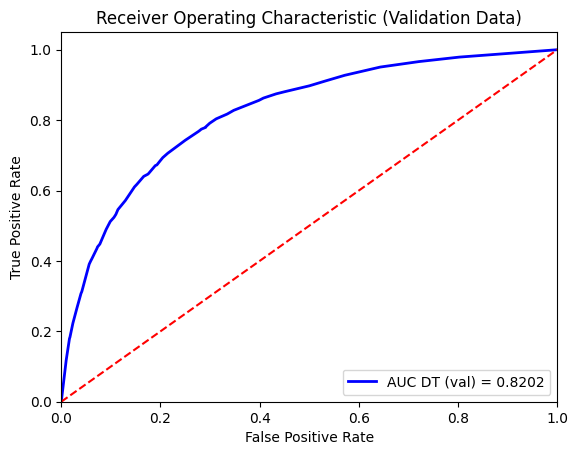

Confusion Matrix for Random Forest:
[[5272 1051]
 [1323 2354]]


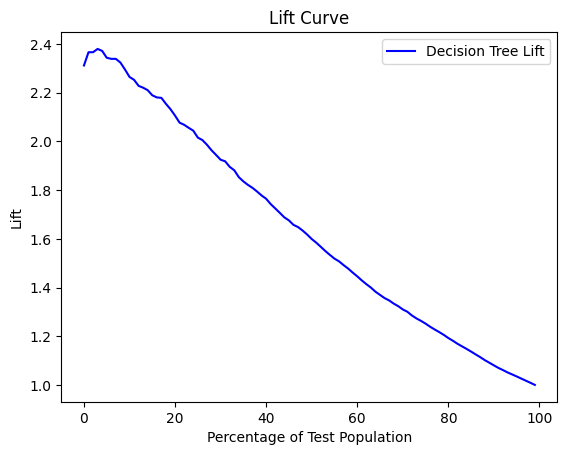

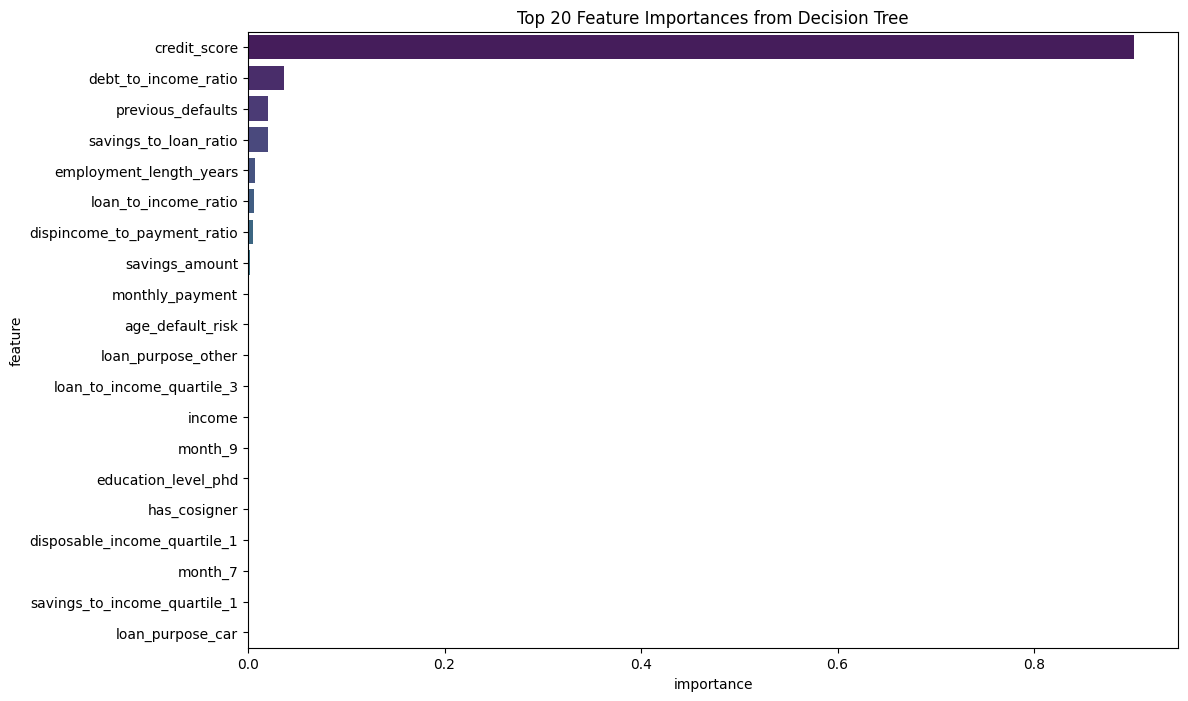

SHAP Feature Importance:


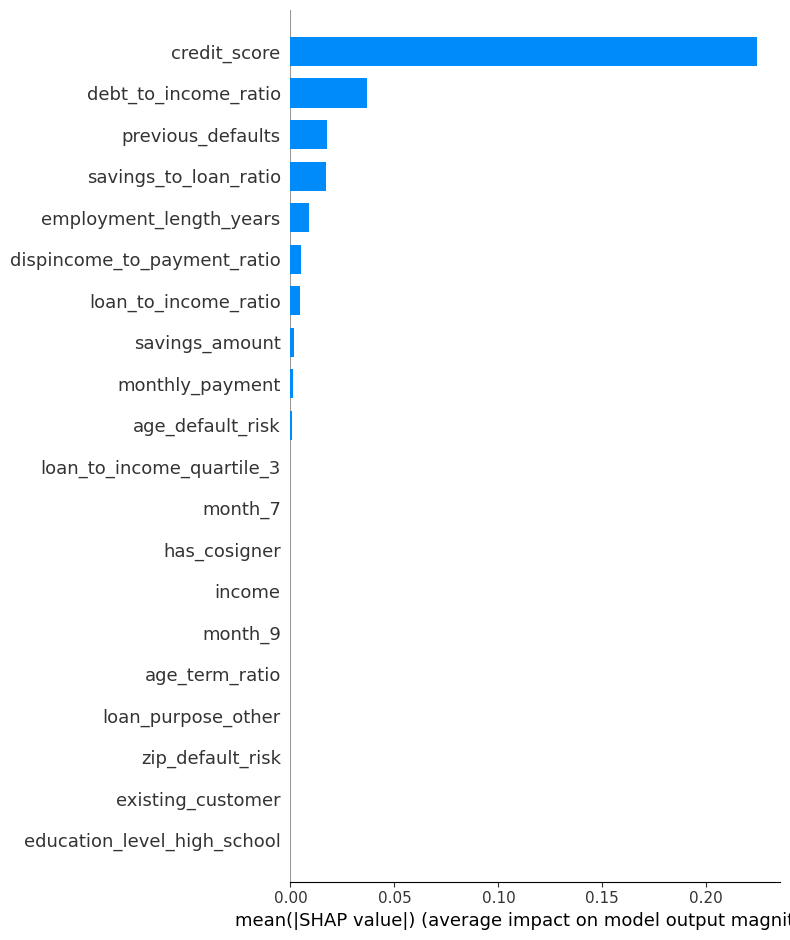

SHAP Value Distribution:


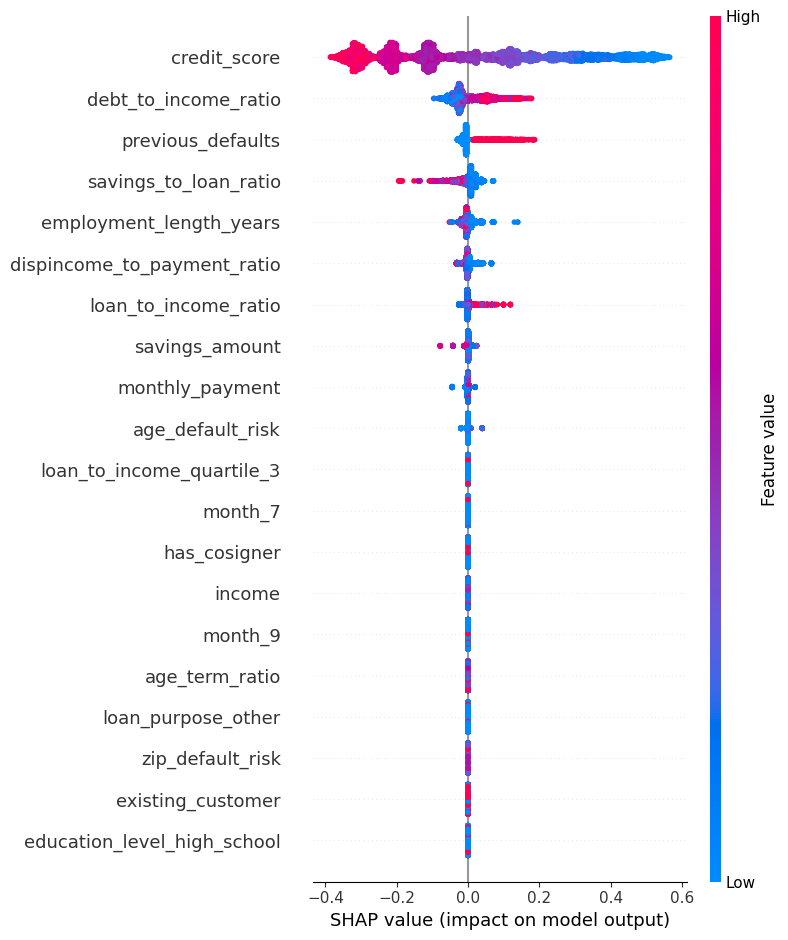

Force Plot for First Sample:


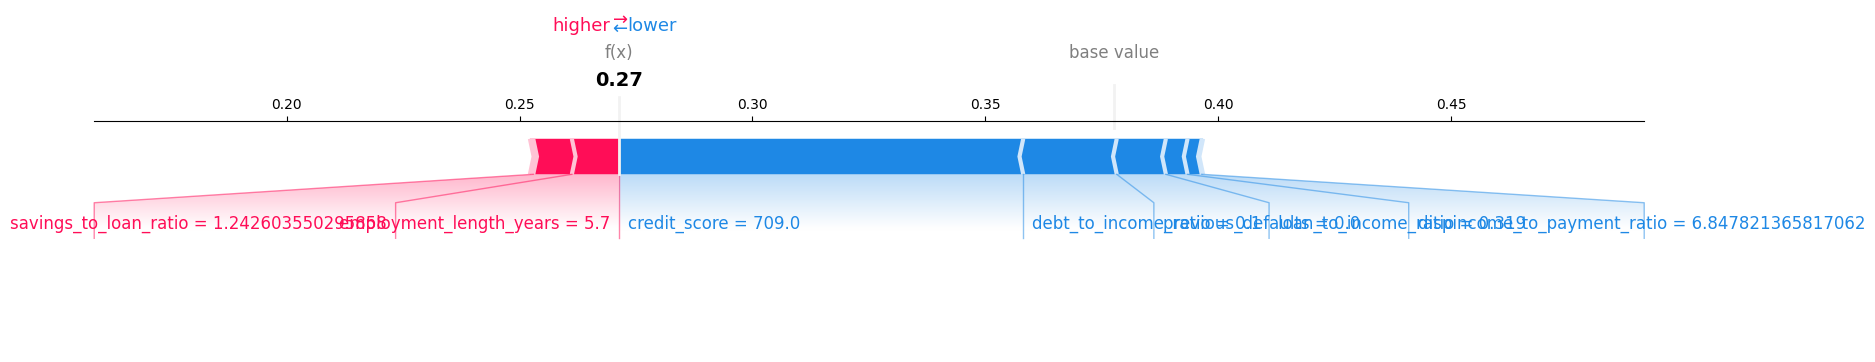


Dependence Plot for 'credit_score':


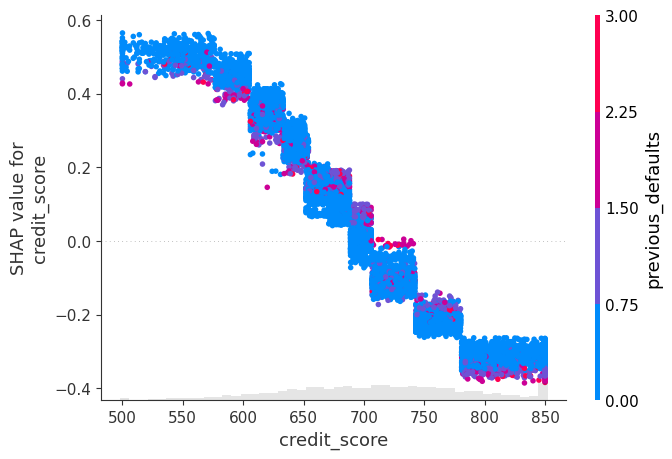


Waterfall Plot for First Sample:


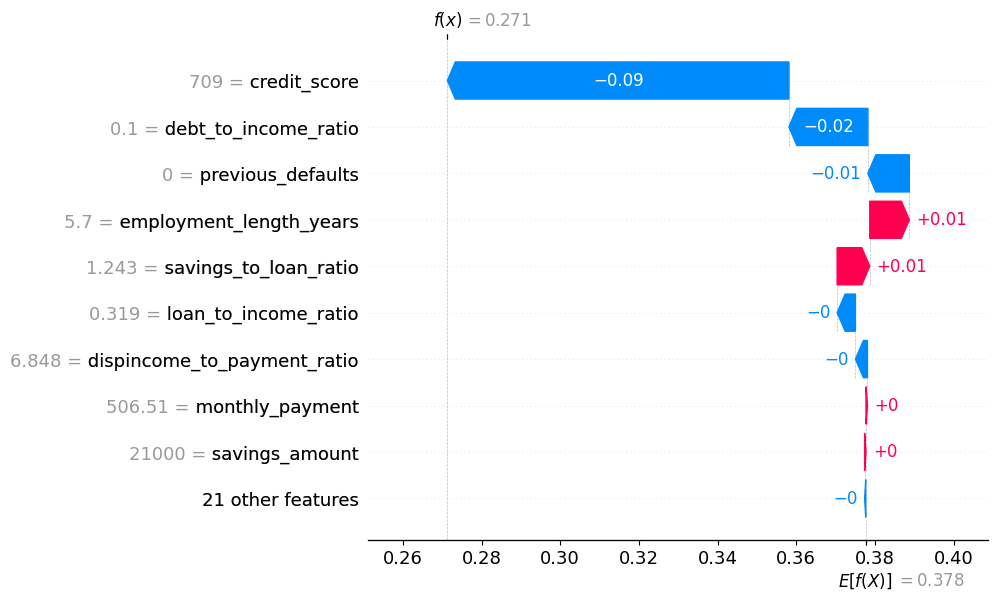

In [ ]:
## Decision Tree with features selected by Logistic Regression
# Define parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 15, 20, 25],  # Controls tree complexity
    'min_samples_split': [2, 5, 10, 20],      # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5, 10, 20, 50],# Minimum samples in a leaf
    'max_leaf_nodes': [None, 20, 50, 100]      # Maximum number of leaf nodes
}

# Initialize Decision Tree Classifier
gridsearch_dt = GridSearchCV(
    DecisionTreeClassifier(criterion='gini'), 
    param_grid_dt, 
    scoring='roc_auc', 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), 
    n_jobs=-1,
    verbose=1
)
gridsearch_dt.fit(X_train_selected, np.ravel(y_train))

# Get the best model
DT = gridsearch_dt.best_estimator_

# Fit the model
y_test_labels_dt = DT.predict(X_test_selected)
y_test_scores_dt = DT.predict_proba(X_test_selected)[:,1]

# Evaluate the model
accuracy_test_dt = accuracy_score(y_test, y_test_labels_dt)
AUC_test_dt = roc_auc_score(y_test, y_test_scores_dt)
print(f"Accuracy Test for Decision Tree: {accuracy_test_dt}")
print(f"AUC Test for Decision Tree: {AUC_test_dt}")
print(f"Best parameters for Decision Tree: {gridsearch_dt.best_params_}")
print(f"Best score for Decision Tree: {gridsearch_dt.best_score_}")

# Plot ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_scores_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.figure()
plt.plot(fpr_dt, tpr_dt, color='blue', lw=2, label=f'AUC DT (val) = {roc_auc_dt:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Validation Data)')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cf_dt = confusion_matrix(y_test, y_test_labels_dt)
print("Confusion Matrix for Decision Tree:")
print(cf_dt)

# Lift Curve
lift_curve_DT = [liftatp(y_test_scores_dt, y_test, (i+1)/100) for i in range(100)]
plt.plot(np.arange(100), lift_curve_DT, 'b', label='Decision Tree Lift')
plt.title('Lift Curve')
plt.xlabel('Percentage of Test Population')
plt.ylabel('Lift')
plt.legend()
plt.show()

# Store evaluation metrics
y_test_evaluation_dt = pd.DataFrame({
    'accuracy': [accuracy_test_dt],
    'AUC': [AUC_test_dt]
})

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': X_selected.columns,
    'importance': DT.feature_importances_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_dt.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Decision Tree')
plt.show()

# Initialize SHAP explainer
explainer_dt = shap.TreeExplainer(DT)

# Calculate SHAP values
shap_values_dt = explainer_dt(X_test_selected)

# For binary classification, use values for class 1
if len(shap_values_dt.shape) == 3:  # (n_samples, n_features, n_classes)
    shap_values_dt = shap_values_dt[..., 1]  # Take values for positive class

# Convert to Explanation object with enforced feature_names
if not isinstance(shap_values_dt, shap.Explanation):
    shap_values_dt = shap.Explanation(
        values=shap_values_dt,
        base_values=explainer_dt.expected_value[1] if len(explainer_dt.expected_value) > 1 else explainer_dt.expected_value,
        data=X_test_selected,
        feature_names=X_selected.columns.tolist()  # Explicitly set feature names
    )
else:
    # Rebuild Explanation if feature_names are missing
    if shap_values_dt.feature_names is None:
        shap_values_dt = shap.Explanation(
            values=shap_values_dt.values,
            base_values=shap_values_dt.base_values,
            data=shap_values_dt.data,
            feature_names=X_selected.columns.tolist()  # Inject feature names
        )

# SHAP visualizations
print("SHAP Feature Importance:")
shap.summary_plot(shap_values_dt, X_test_selected, feature_names=X_selected.columns, plot_type="bar")

print("SHAP Value Distribution:")
shap.summary_plot(shap_values_dt, X_test_selected, feature_names=X_selected.columns)

print("Force Plot for First Sample:")
shap.initjs()
shap.plots.force(shap_values_dt[0], matplotlib=True)

most_important_feature_dt = feature_importance_dt.iloc[0]['feature']
feature_idx_rf = X_selected.columns.get_loc(most_important_feature_dt)
print(f"\nDependence Plot for '{most_important_feature_dt}':")
shap.plots.scatter(shap_values_dt[:, feature_idx_rf], color=shap_values_dt)

print("\nWaterfall Plot for First Sample:")
shap.plots.waterfall(shap_values_dt[0])

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Accuracy Test for Random Forest: 0.7728
AUC Test for Random Forest: 0.8311985145940346
Best parameters for Random Forest: {'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best score for Random Forest: 0.8267349794817076


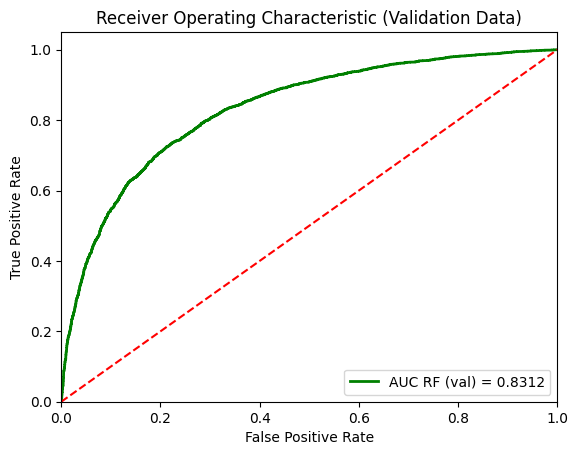

Confusion Matrix for Random Forest:
[[5388  935]
 [1337 2340]]


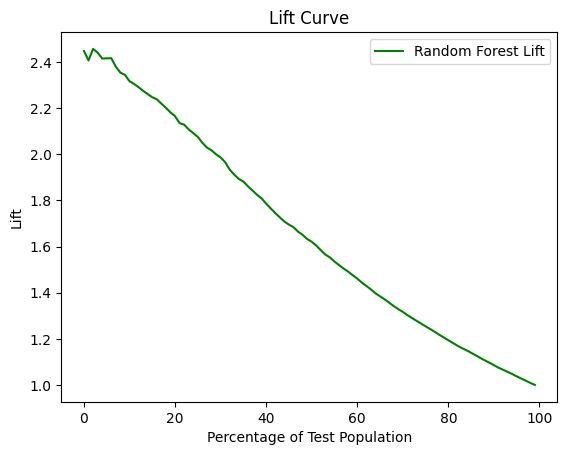

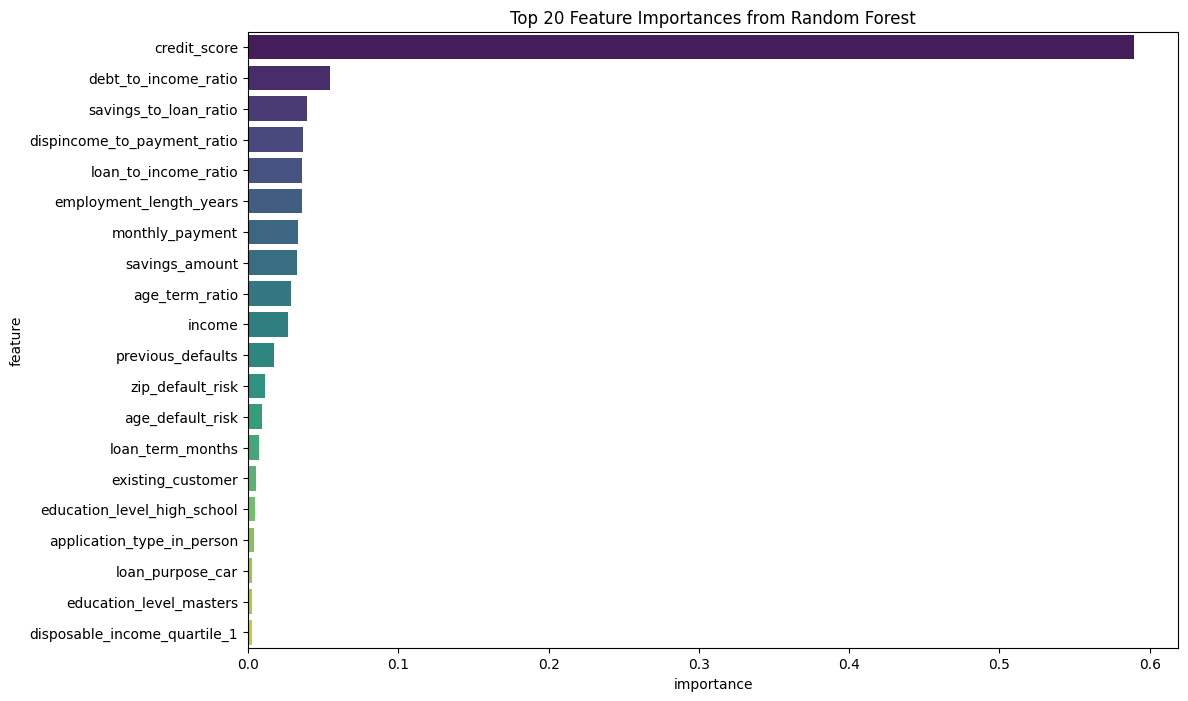

SHAP Feature Importance:


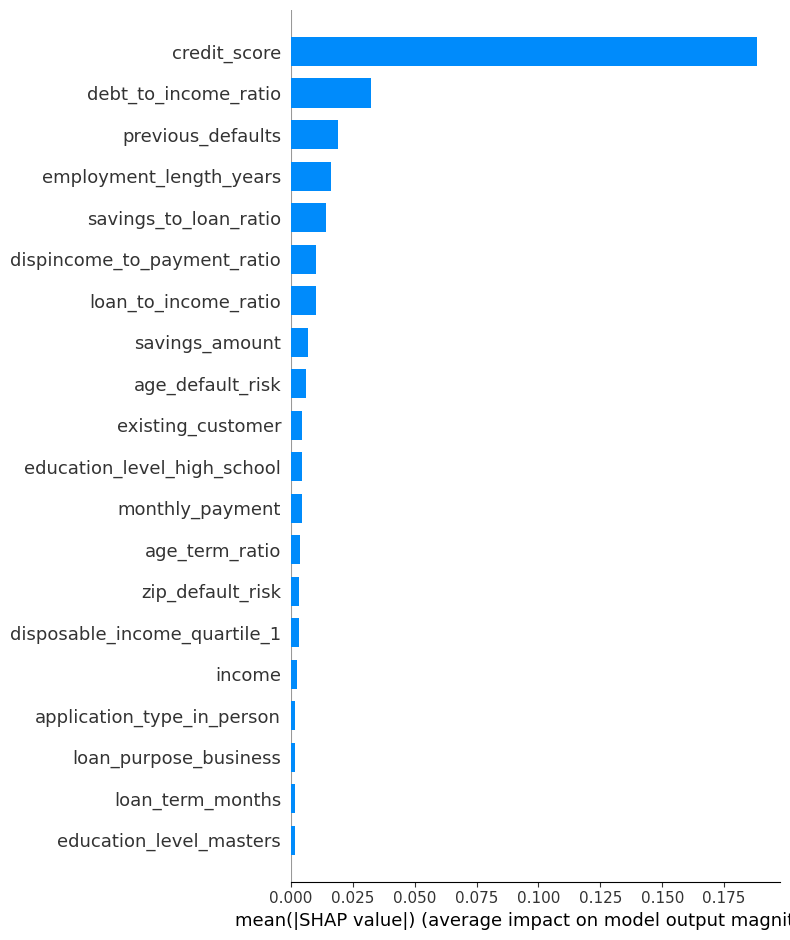

SHAP Value Distribution:


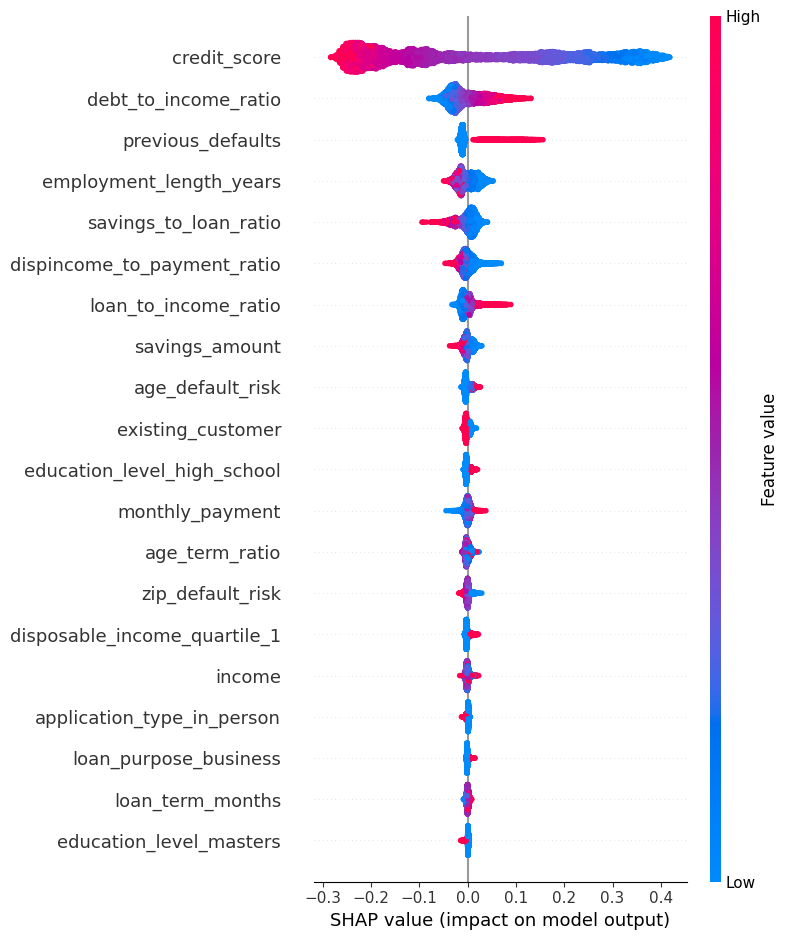

Force Plot for First Sample:


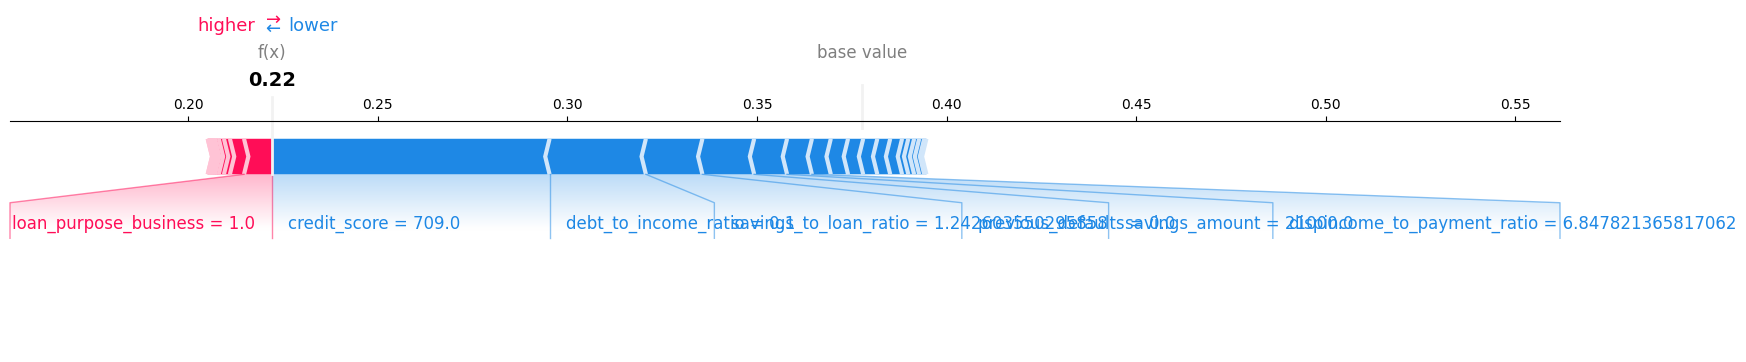


Dependence Plot for 'credit_score':


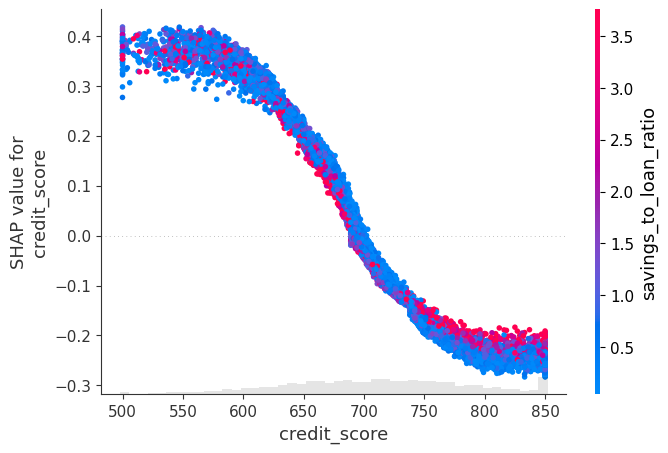


Waterfall Plot for First Sample:


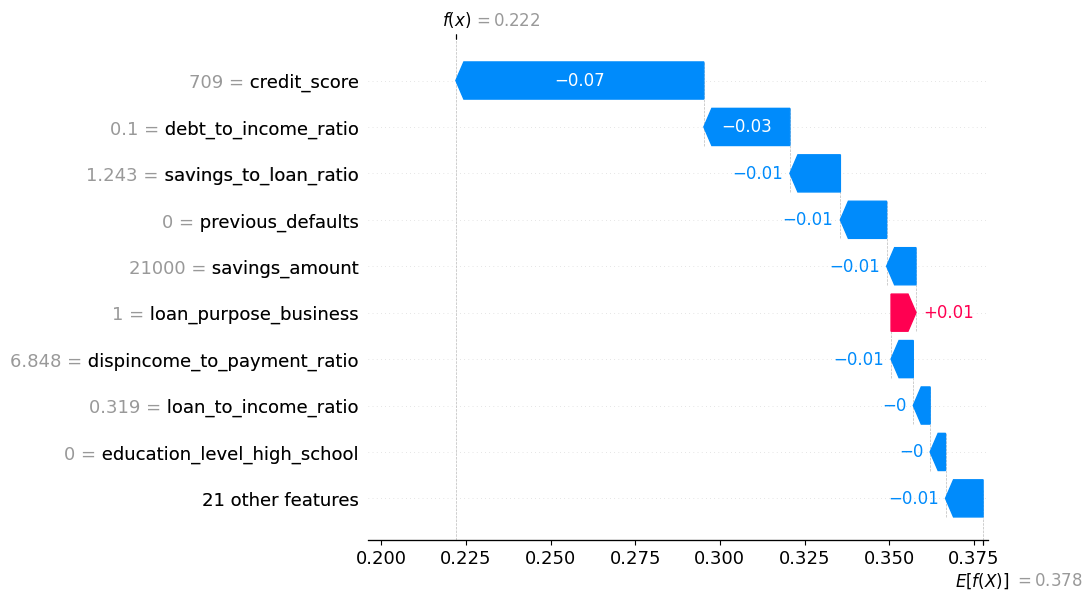

In [ ]:
## Random Forest
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],        # Number of trees in the forest
    'max_depth': [None, 5, 10, 15, 20, 25], # Maximum depth of individual trees
    'min_samples_split': [2, 5, 10, 20],     # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 5, 10, 20, 50], # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2'],        # Number of features to consider for splits
    'bootstrap': [True, False]               # Whether to bootstrap samples
}

gridsearch_rf = GridSearchCV(
    RandomForestClassifier(criterion='gini', n_jobs=-1), 
    param_grid_rf, 
    scoring='roc_auc', 
    cv=5, 
    n_jobs=-1,
    verbose=1
)
gridsearch_rf.fit(X_train_selected, np.ravel(y_train))

RF = gridsearch_rf.best_estimator_

# Generate predictions
y_test_labels_rf = RF.predict(X_test_selected)
y_test_scores_rf = RF.predict_proba(X_test_selected)[:,1]

# Evaluate performance
accuracy_test_rf = accuracy_score(y_test, y_test_labels_rf)
AUC_test_rf = roc_auc_score(y_test, y_test_scores_rf)
print(f"Accuracy Test for Random Forest: {accuracy_test_rf}")
print(f"AUC Test for Random Forest: {AUC_test_rf}")
print(f"Best parameters for Random Forest: {gridsearch_rf.best_params_}")
print(f"Best score for Random Forest: {gridsearch_rf.best_score_}")

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_scores_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'AUC RF (val) = {roc_auc_rf:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Validation Data)')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cf_rf = confusion_matrix(y_test, y_test_labels_rf)
print("Confusion Matrix for Random Forest:")
print(cf_rf)

# Lift Curve
lift_curve_RF = [liftatp(y_test_scores_rf, y_test, (i+1)/100) for i in range(100)]
plt.plot(np.arange(100), lift_curve_RF, 'g', label='Random Forest Lift')
plt.title('Lift Curve')
plt.xlabel('Percentage of Test Population')
plt.ylabel('Lift')
plt.legend()
plt.show()

# Store metrics
y_test_evaluation_rf = pd.DataFrame({
    'accuracy': [accuracy_test_rf],
    'AUC': [AUC_test_rf]
})

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': X_selected.columns,
    'importance': RF.feature_importances_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_rf.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Random Forest')
plt.show()

# SHAP Explainability
explainer_rf = shap.TreeExplainer(RF)
shap_values_rf = explainer_rf(X_test_selected)

# Handle SHAP values for binary classification
if len(shap_values_rf.shape) == 3:
    shap_values_rf = shap_values_rf[..., 1]

# Ensure proper Explanation object
if not isinstance(shap_values_rf, shap.Explanation):
    shap_values_rf = shap.Explanation(
        values=shap_values_rf,
        base_values=explainer_rf.expected_value[1] if len(explainer_rf.expected_value) > 1 else explainer_rf.expected_value,
        data=X_test_selected,
        feature_names=X_selected.columns.tolist()
    )

# SHAP visualizations
print("SHAP Feature Importance:")
shap.summary_plot(shap_values_rf, X_test_selected, feature_names=X_selected.columns, plot_type="bar")

print("SHAP Value Distribution:")
shap.summary_plot(shap_values_rf, X_test_selected, feature_names=X_selected.columns)

print("Force Plot for First Sample:")
shap.initjs()
shap.plots.force(shap_values_rf[0], matplotlib=True)

most_important_feature_rf = feature_importance_rf.iloc[0]['feature']
feature_idx_rf = X_selected.columns.get_loc(most_important_feature_rf)
print(f"\nDependence Plot for '{most_important_feature_rf}':")
shap.plots.scatter(shap_values_rf[:, feature_idx_rf], color=shap_values_rf)

print("\nWaterfall Plot for First Sample:")
shap.plots.waterfall(shap_values_rf[0])

Fitting 5 folds for each of 8748 candidates, totalling 43740 fits
Accuracy Test for XGBoost: 0.7740
AUC Test for XGBoost: 0.8347
Best parameters for XGBoost: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 10, 'subsample': 0.8}
Best score for XGBoost: 0.8313


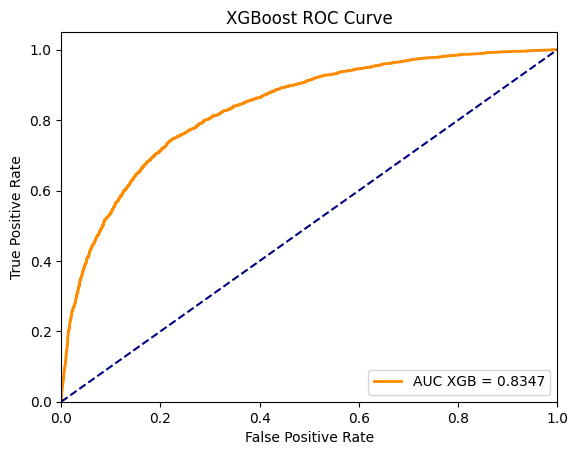

Confusion Matrix for XGBoost:
[[5379  944]
 [1316 2361]]


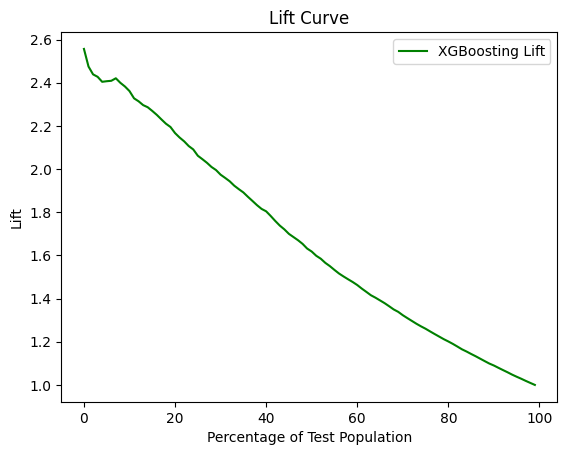

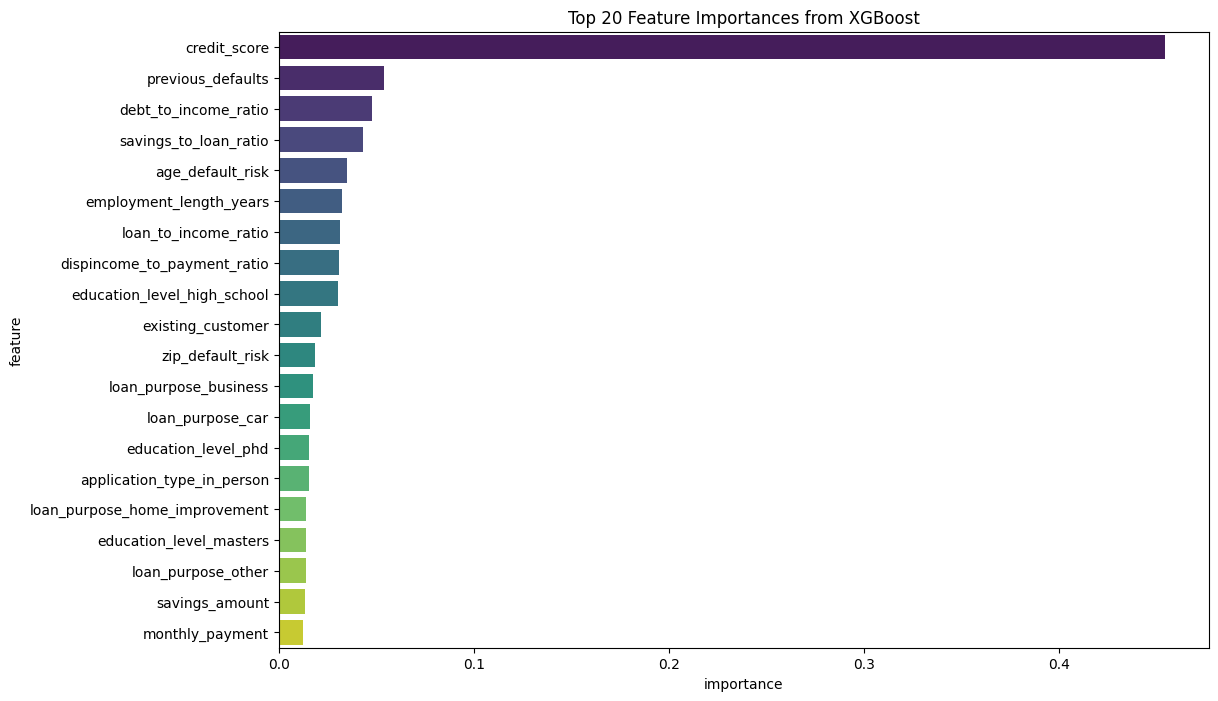

SHAP Feature Importance:


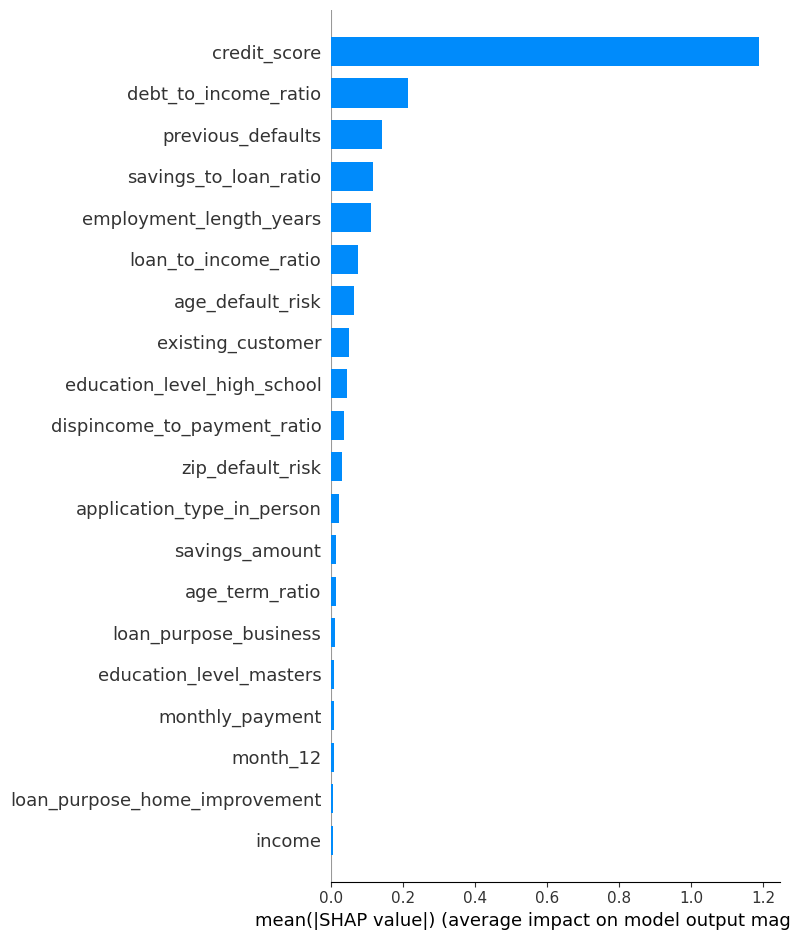


SHAP Value Distribution:


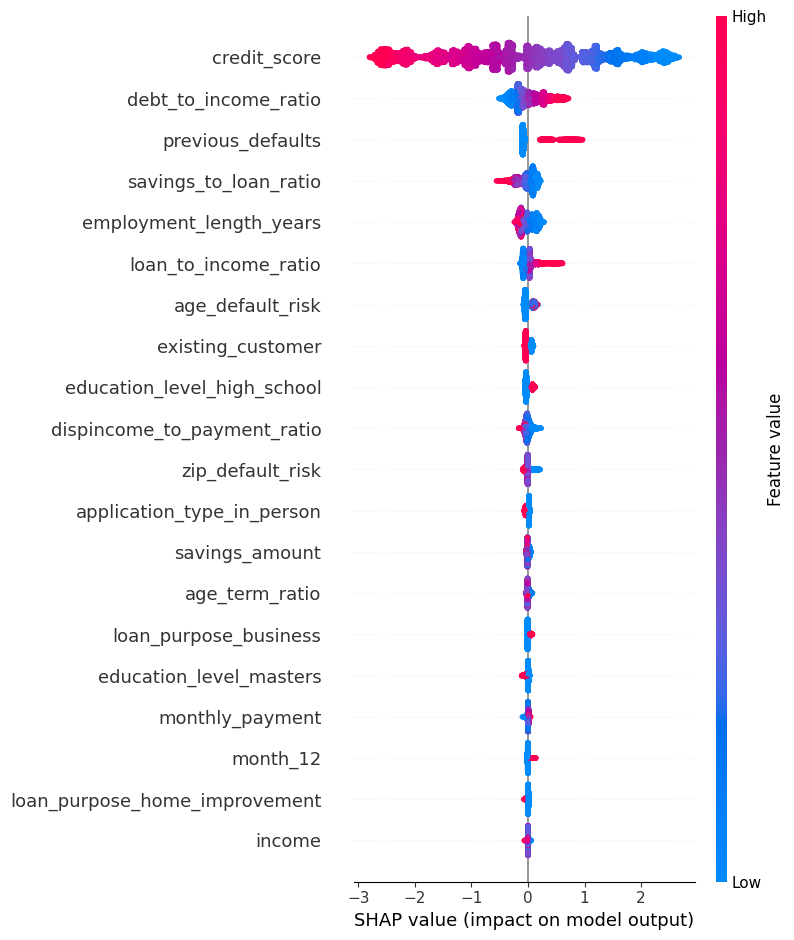


Force Plot for First Sample:


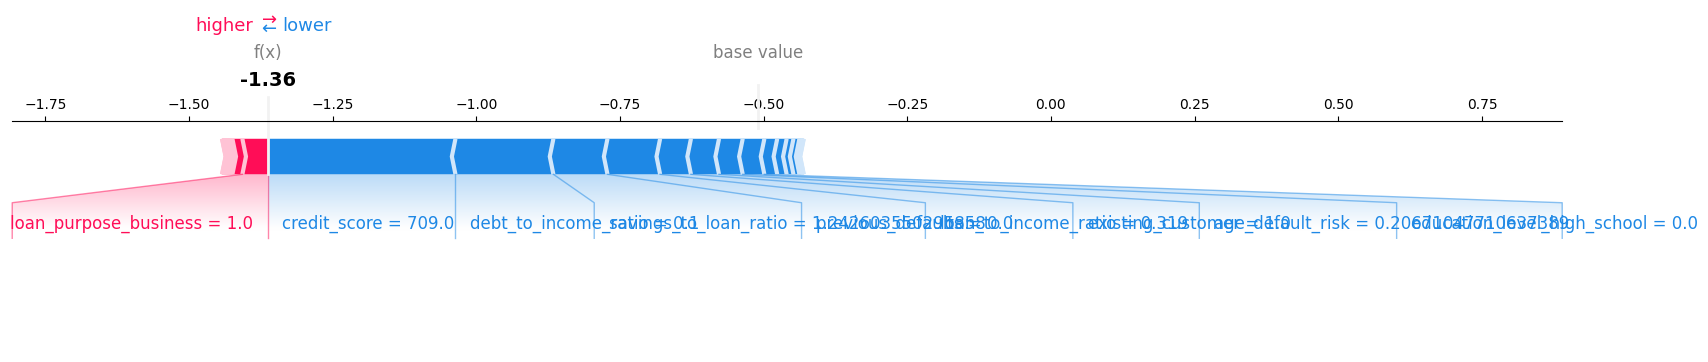


Dependence Plot for 'credit_score':


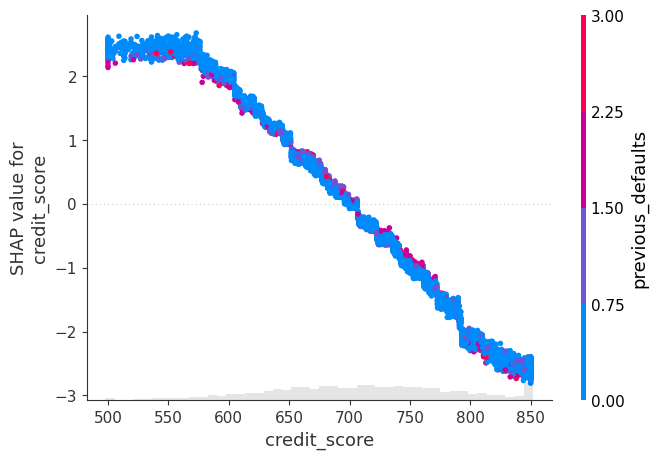


Waterfall Plot for First Sample:


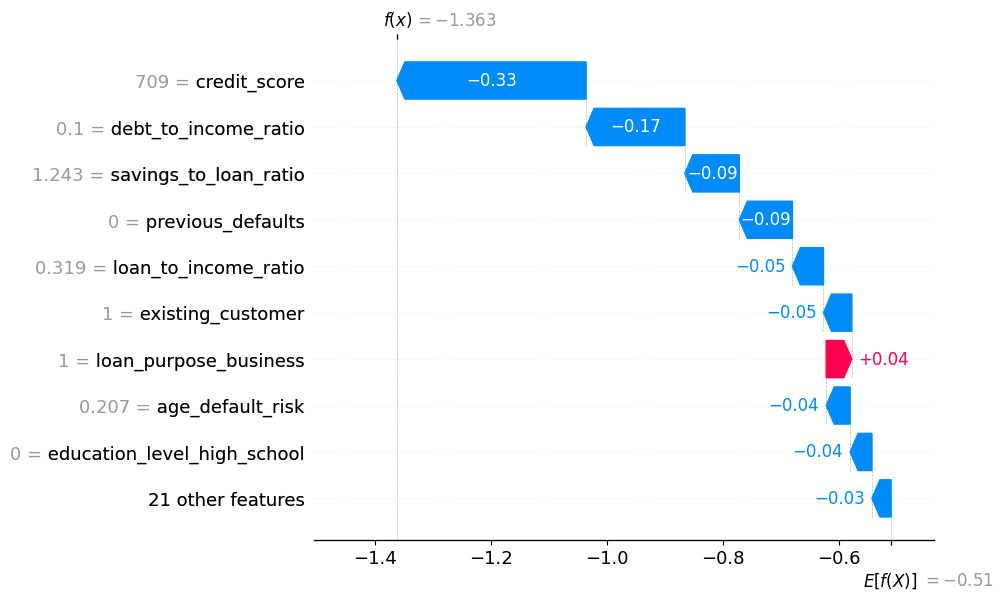

In [26]:
## XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],       # Number of trees
    'max_depth': [3, 5, 7, 9],          # Maximum depth of trees
    'learning_rate': [0.01, 0.1, 0.3], # Step size shrinkage
    'subsample': [0.6, 0.8, 1.0],     # Fraction of samples to use for fitting
    'colsample_bytree': [0.6, 0.8, 1.0], # Fraction of features to use for fitting
    'gamma': [0, 0.1, 0.3],        # Minimum loss reduction to make a further partition
    'reg_alpha': [0, 0.1, 1],  # L1 regularization
    'reg_lambda': [0, 1, 10]   # L2 regularization
}

# Create XGBoost classifier
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=10,
    enable_categorical=False, # Explicitly disable categorical feature handling if not needed
    n_jobs=-1,
)

# Define the grid search
gridsearch_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the model with validation set for early stopping
gridsearch_xgb.fit(
    X_train_selected, 
    np.ravel(y_train),
    eval_set=[(X_test_selected, y_test)],
    verbose=False
)

# Get best estimator
XGB = gridsearch_xgb.best_estimator_

# Generate predictions
y_test_labels_xgb = XGB.predict(X_test_selected)
y_test_scores_xgb = XGB.predict_proba(X_test_selected)[:,1]

# Evaluate performance
accuracy_test_xgb = accuracy_score(y_test, y_test_labels_xgb)
AUC_test_xgb = roc_auc_score(y_test, y_test_scores_xgb)
print(f"Accuracy Test for XGBoost: {accuracy_test_xgb:.4f}")
print(f"AUC Test for XGBoost: {AUC_test_xgb:.4f}")
print(f"Best parameters for XGBoost: {gridsearch_xgb.best_params_}")
print(f"Best score for XGBoost: {gridsearch_xgb.best_score_:.4f}")

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_scores_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'AUC XGB = {roc_auc_xgb:.4f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cf_xgb = confusion_matrix(y_test, y_test_labels_xgb)
print("Confusion Matrix for XGBoost:")
print(cf_xgb)

# Lift Curve
lift_curve_XGB = [liftatp(y_test_scores_xgb, y_test, (i+1)/100) for i in range(100)]
plt.plot(np.arange(100), lift_curve_XGB, 'g', label='XGBoosting Lift')
plt.title('Lift Curve')
plt.xlabel('Percentage of Test Population')
plt.ylabel('Lift')
plt.legend()
plt.show()

# Store metrics
y_test_evaluation_xgb = pd.DataFrame({
    'accuracy': [accuracy_test_xgb],
    'AUC': [AUC_test_xgb]
})

# Feature Importance
feature_importance_xgb = pd.DataFrame({
    'feature': X_selected.columns,
    'importance': XGB.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_xgb.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from XGBoost')
plt.show()

# SHAP Explainability
explainer_xgb = shap.TreeExplainer(XGB)
shap_values_xgb = explainer_xgb(X_test_selected)

# Handle SHAP values for binary classification
if len(shap_values_xgb.shape) == 3:
    shap_values_xgb = shap_values_xgb[..., 1]

# Ensure proper Explanation object
if not isinstance(shap_values_xgb, shap.Explanation):
    shap_values_xgb = shap.Explanation(
        values=shap_values_xgb,
        base_values=explainer_xgb.expected_value,
        data=X_test_selected,
        feature_names=X_selected.columns.tolist()
    )

# SHAP visualizations
print("SHAP Feature Importance:")
shap.summary_plot(shap_values_xgb, X_test_selected, feature_names=X_selected.columns, plot_type="bar")

print("\nSHAP Value Distribution:")
shap.summary_plot(shap_values_xgb, X_test_selected, feature_names=X_selected.columns)

print("\nForce Plot for First Sample:")
shap.initjs()
shap.plots.force(shap_values_xgb[0], matplotlib=True)

most_important_feature_xgb = feature_importance_xgb.iloc[0]['feature']
feature_idx_xgb = X_selected.columns.get_loc(most_important_feature_xgb)
print(f"\nDependence Plot for '{most_important_feature_xgb}':")
shap.plots.scatter(shap_values_xgb[:, feature_idx_xgb], color=shap_values_xgb)

print("\nWaterfall Plot for First Sample:")
shap.plots.waterfall(shap_values_xgb[0])


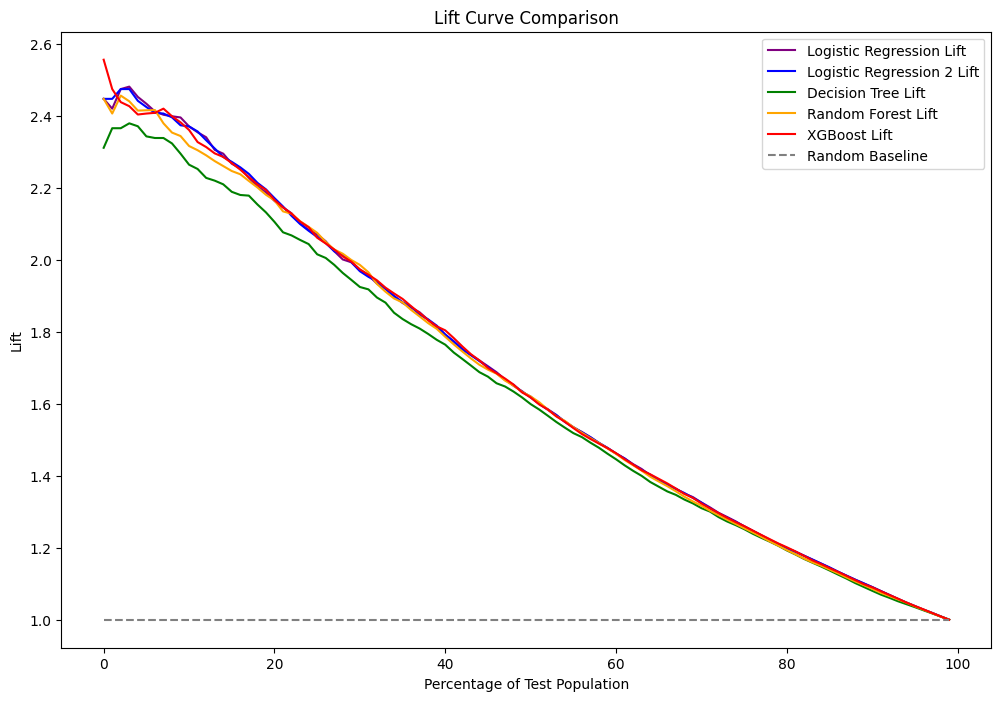

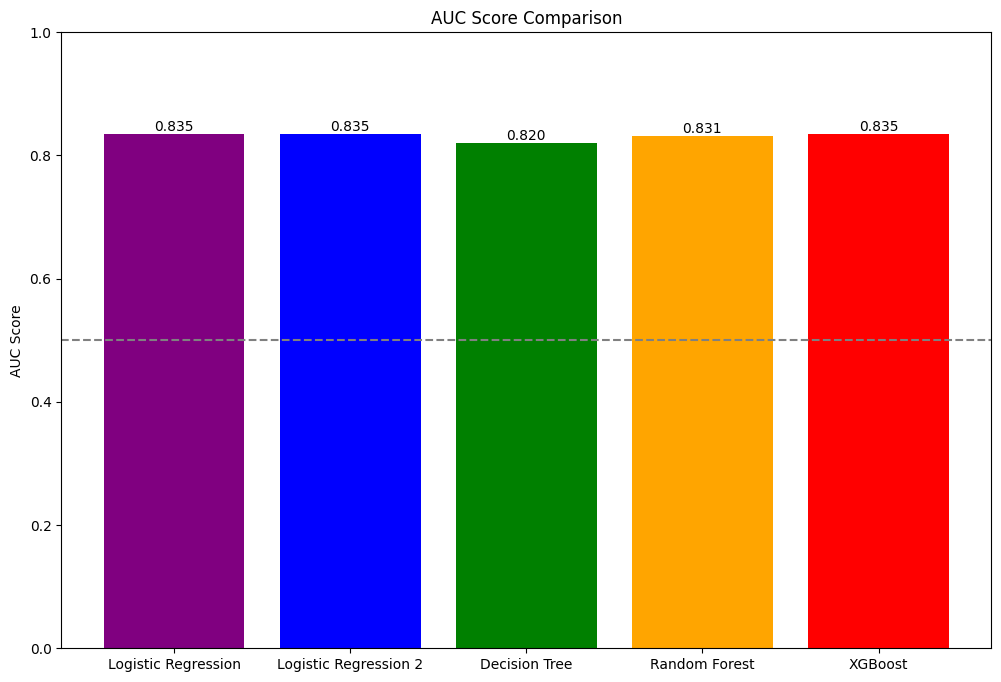

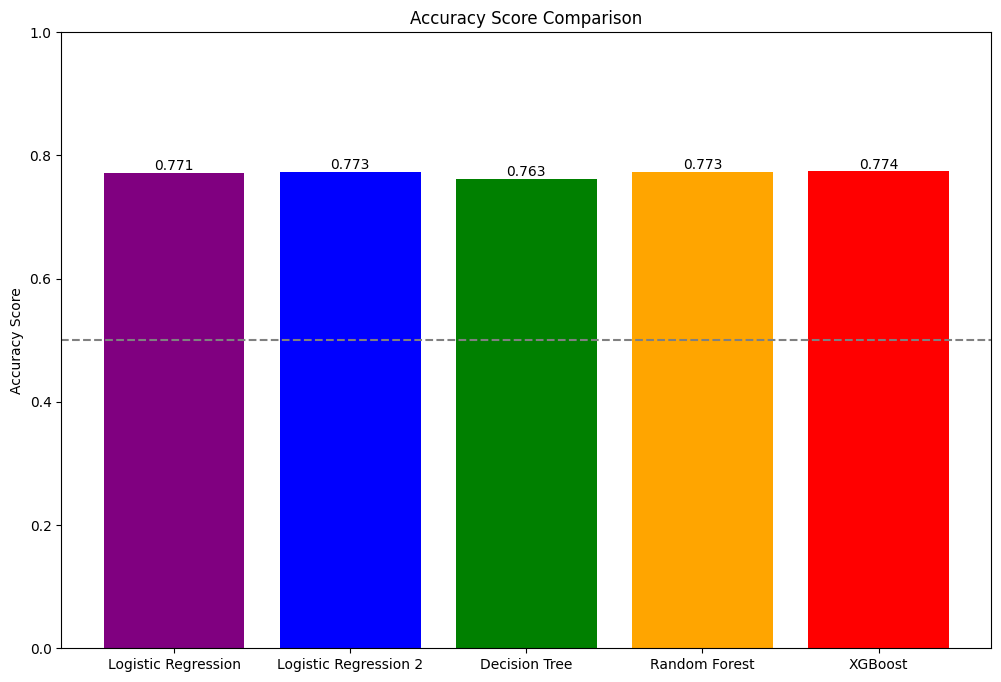

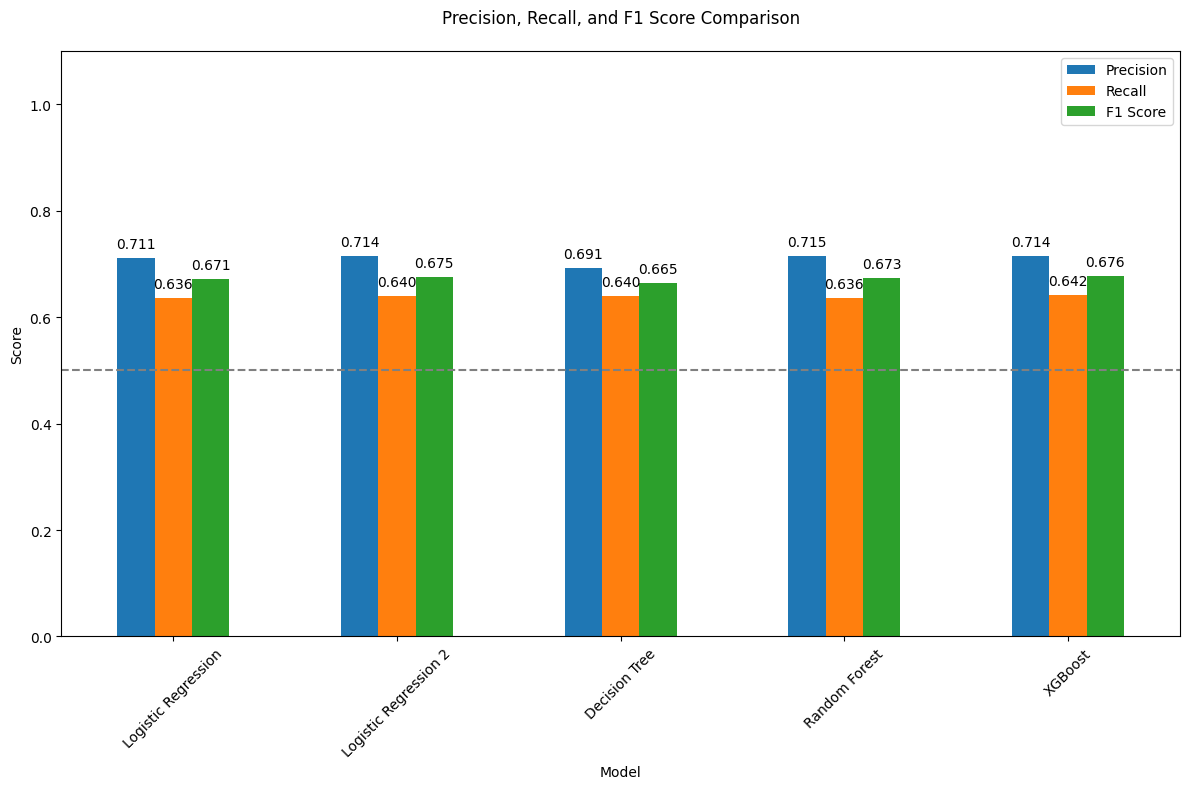

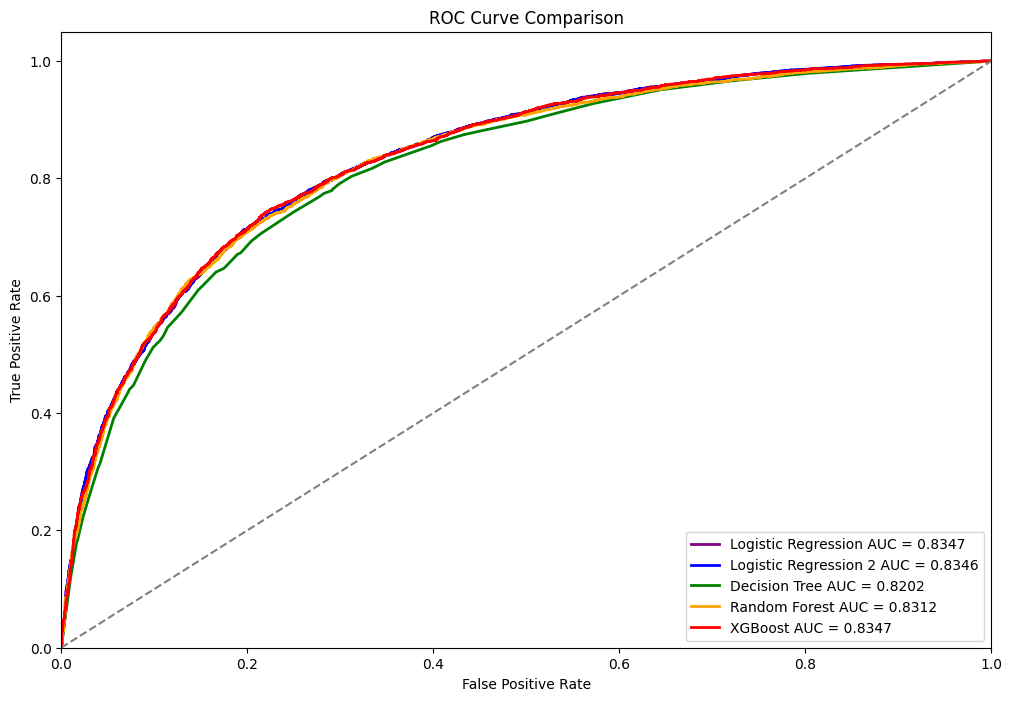

In [ ]:
## Compare all the LIFT curves and random baseline
plt.figure(figsize=(12, 8))
plt.plot(np.arange(100), lift_curve_LR, 'purple', label='Logistic Regression Lift')
plt.plot(np.arange(100), lift_curve_LR2, 'blue', label='Logistic Regression 2 Lift')
plt.plot(np.arange(100), lift_curve_DT, 'green', label='Decision Tree Lift')
plt.plot(np.arange(100), lift_curve_RF, 'orange', label='Random Forest Lift')
plt.plot(np.arange(100), lift_curve_XGB, 'red', label='XGBoost Lift')
plt.plot(np.arange(100), [1]*100, 'grey', linestyle='--', label='Random Baseline')
plt.title('Lift Curve Comparison')
plt.xlabel('Percentage of Test Population')
plt.ylabel('Lift')
plt.legend()
plt.savefig('lift_curve_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



## Compare all the AUC scores
plt.figure(figsize=(12, 8))
bars_auc = plt.bar(['Logistic Regression', 'Logistic Regression 2', 'Decision Tree', 'Random Forest', 'XGBoost'],
               [AUC_test_lr, AUC_test_lr2, AUC_test_dt, AUC_test_rf, AUC_test_xgb],
               color=['purple', 'blue', 'green', 'orange', 'red'])
plt.title('AUC Score Comparison')
plt.ylabel('AUC Score')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='grey', linestyle='--')
for bar in bars_auc:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')
plt.savefig('auc_score_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## Compare accuracy scores
plt.figure(figsize=(12, 8))
bars_acc = plt.bar(['Logistic Regression', 'Logistic Regression 2', 'Decision Tree', 'Random Forest', 'XGBoost'],
        [accuracy_test_lr, accuracy_test_lr2, accuracy_test_dt, accuracy_test_rf, accuracy_test_xgb],
        color=['purple', 'blue', 'green', 'orange', 'red'])
plt.title('Accuracy Score Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='grey', linestyle='--')
for bar in bars_acc:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom')
plt.savefig('accuracy_score_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Calculate precision, recall, and F1 score for each model and plot
models = {
    'Logistic Regression': y_test_labels_lr,
    'Logistic Regression 2': y_test_labels_lr2,
    'Decision Tree': y_test_labels_dt,
    'Random Forest': y_test_labels_rf,
    'XGBoost': y_test_labels_xgb
}
metrics = []
for name, preds in models.items():
    metrics.append({
        'Model': name,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds)
    })
metrics_df = pd.DataFrame(metrics)
ax = metrics_df.set_index('Model').plot(kind='bar', figsize=(12, 8))
plt.title('Precision, Recall, and F1 Score Comparison', pad=20)
plt.ylabel('Score')
plt.ylim(0, 1.1)  # Extra space for annotations
plt.axhline(y=0.5, color='grey', linestyle='--')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 10), 
        textcoords='offset points'
    )
plt.tight_layout()
plt.savefig('prf1_score_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


## Compare all the ROC curves
plt.figure(figsize=(12, 8))
plt.plot(fpr_lr, tpr_lr, color='purple', lw=2, label=f'Logistic Regression AUC = {roc_auc_lr:.4f}')
plt.plot(fpr_lr2, tpr_lr2, color='blue', lw=2, label=f'Logistic Regression 2 AUC = {roc_auc_lr2:.4f}')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree AUC = {roc_auc_dt:.4f}')
plt.plot(fpr_rf, tpr_rf, color='orange', lw=2, label=f'Random Forest AUC = {roc_auc_rf:.4f}')
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost AUC = {roc_auc_xgb:.4f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()